In [47]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# All trade combiantions baseline 
SUMMARY_DIR = Path("./results_merged")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()


ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)

myopic_base = (
    df.sort_values("da_profit", ascending=False)
    .groupby("day", as_index=False)
    .first()[["day", "profit"]]
    .rename(columns={"profit": "myopic_base"})
)


df = df.merge(ri_base, on="day", how="left")
df["uplift_ri_base_abs"] = df["profit"] - df["RI_base"]
df["uplift_ri_base_pct"] = df["uplift_ri_base_abs"] / df["RI_base"]




df = df.merge(myopic_base, on="day", how="left")
df["uplift_myopic_abs"] = df["profit"] - df["myopic_base"]
df["uplift_myopic_pct"] = df["uplift_myopic_abs"] / df["myopic_base"] 

In [48]:
# Folder for plots

import os
folder = "plots"
os.makedirs(folder, exist_ok=True)

#### Set time range

In [49]:
start_date = pd.Timestamp("2019-01-01", tz="UTC")
end_date = pd.Timestamp("2025-12-31", tz="UTC")

df = df.loc[(df["day"] >= start_date) & (df["day"] <= end_date)].copy()

df.loc[(df["sell_hour"].isna()), "sell_hour"] = 0
df.loc[(df["buy_hour"].isna()), "buy_hour"] = 0

#### RI trafing path

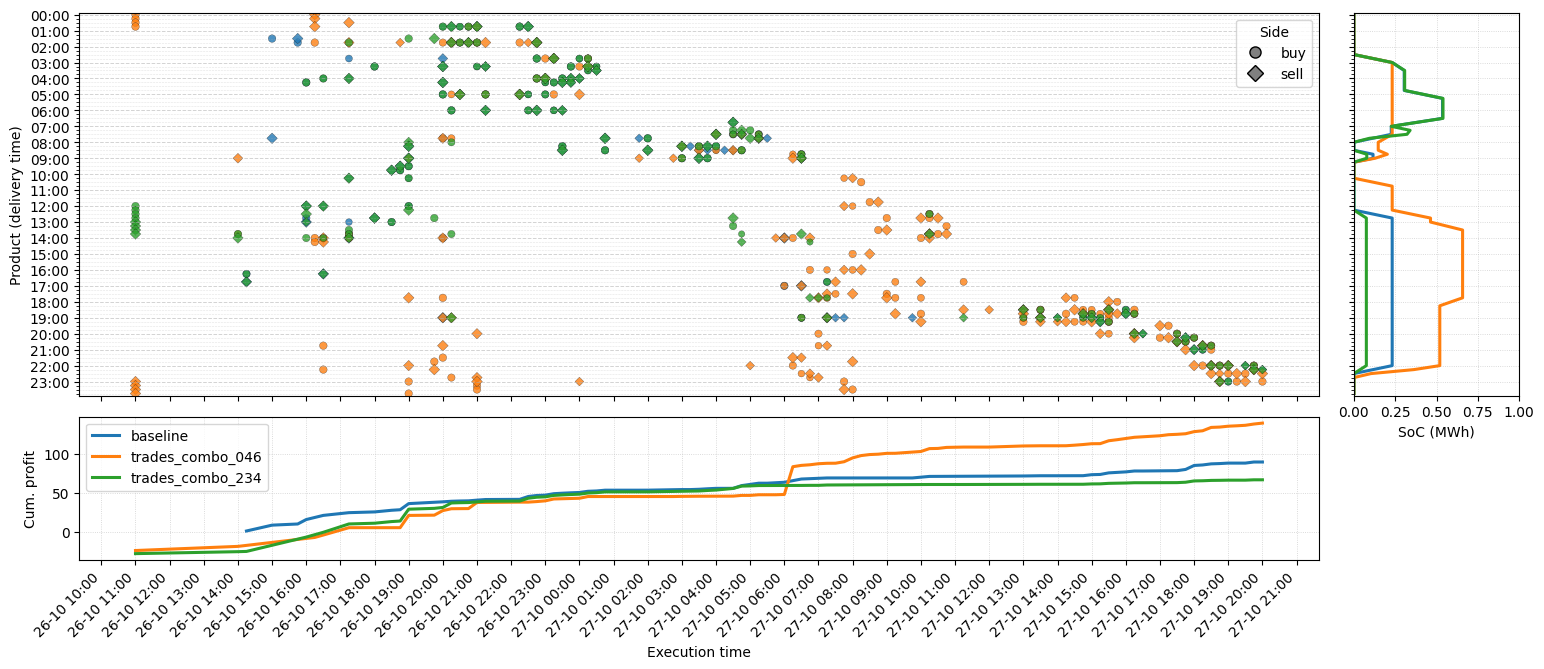

In [55]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# name plot
name = "ri_trades_profit_soc"

# ============================================================
# Helpers
# ============================================================
def _prep_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["execution_time"] = pd.to_datetime(df["execution_time"])
    df["product"] = pd.to_datetime(df["product"])

    # product → 15-min slot index (0..95)
    df["prod_min"] = df["product"].dt.hour * 60 + df["product"].dt.minute
    df["prod_slot_15m"] = (df["prod_min"] // 15).astype(int)

    df["side"] = df["side"].str.lower().str.strip()
    df = df[df["side"].isin(["buy", "sell"])]

    df["quantity"] = df["quantity"].astype(float)
    df["profit"] = df["profit"].astype(float)

    df.loc[df["quantity"].abs() < 1e-10, "quantity"] = 0.0
    return df


def _soc_by_product_slots(
    df_run: pd.DataFrame,
    E_max_mwh: float,
    soc0_mwh: float,
    dt_hours: float,
    eta_ch: float,
    eta_dis: float,
) -> Tuple[np.ndarray, np.ndarray]:
    sign = df_run["side"].map({"buy": +1.0, "sell": -1.0}).astype(float)
    p_signed = sign * df_run["quantity"].astype(float)

    sched = (
        pd.DataFrame({"slot": df_run["prod_slot_15m"], "p_mw_signed": p_signed})
        .groupby("slot", as_index=False)["p_mw_signed"]
        .sum()
        .sort_values("slot")
    )

    # ensure full 0..95 grid
    full = pd.DataFrame({"slot": np.arange(0, 96)})
    sched = full.merge(sched, on="slot", how="left").fillna({"p_mw_signed": 0.0})

    e_slot = sched["p_mw_signed"].to_numpy() * dt_hours
    e_batt = np.where(e_slot >= 0, e_slot * eta_ch, e_slot / eta_dis)

    soc = np.empty(len(e_batt) + 1)
    soc[0] = soc0_mwh
    for i in range(len(e_batt)):
        soc[i + 1] = np.clip(soc[i] + e_batt[i], 0.0, E_max_mwh)

    # map SoC to slot centers (0..95) → perfect alignment
    soc_center = 0.5 * (soc[:-1] + soc[1:])
    y_slots = np.arange(0, 96)

    return y_slots, soc_center


# ============================================================
# Main plot
# ============================================================
def plot_ri_trades_profit_soc(
    csv_paths: Sequence[str | Path],
    title: Optional[str] = None,
    run_labels: Optional[Dict[str, str]] = None,
    # scatter
    size_by_quantity: bool = True,
    quantity_size_scale: float = 10.0,
    alpha: float = 0.9,
    # SoC params
    E_max_mwh: float = 1.0,
    soc0_mwh: float = 0.5,
    dt_hours: float = 0.25,
    eta_ch: float = 1.0,
    eta_dis: float = 1.0,
):
    csv_paths = [Path(p) for p in csv_paths]
    if not csv_paths:
        raise ValueError("csv_paths is empty")

    # load data
    dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)
        df = _prep_trades(df)
        df["run"] = p.stem
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True)

    runs = sorted(df_all["run"].unique())
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {run: colors[i % len(colors)] for i, run in enumerate(runs)}
    marker_map = {"buy": "o", "sell": "D"}

    def _sizes(q):
        if not size_by_quantity:
            return np.full_like(q, 60.0)
        qabs = np.abs(q)
        return 20 + quantity_size_scale * np.sqrt(qabs / (qabs.max() + 1e-12))

    # ========================================================
    # Layout
    # ========================================================
    fig = plt.figure(figsize=(16, 7.5))
    gs = GridSpec(
        2, 2,
        height_ratios=[3.2, 1.2],
        width_ratios=[4.5, 0.6],
        hspace=0.08,
        wspace=0.05,
    )

    ax_trades = fig.add_subplot(gs[0, 0])
    ax_profit = fig.add_subplot(gs[1, 0], sharex=ax_trades)
    ax_soc = fig.add_subplot(gs[0, 1], sharey=ax_trades)
    ax_dummy = fig.add_subplot(gs[1, 1])  # keeps SoC x-labels alive
    ax_dummy.axis("off")

    # ========================================================
    # Plot per run
    # ========================================================
    
    for run in runs:
        df_run = df_all[df_all["run"] == run]
        c = color_map[run]
        label = run_labels.get(run, run) if run_labels else run

        # trades
        for side in ["buy", "sell"]:
            d = df_run[df_run["side"] == side]
            ax_trades.scatter(
                d["execution_time"],
                d["prod_slot_15m"],
                s=_sizes(d["quantity"].to_numpy()),
                color=c,
                marker=marker_map[side],
                alpha=0.8,
                edgecolors="black",
                linewidths=0.2,
            )

        # profit
        prof = (
            df_run.groupby("execution_time", as_index=False)["profit"]
            .sum()
            .sort_values("execution_time")
        )
        prof["cum_profit"] = prof["profit"].cumsum()
        ax_profit.plot(prof["execution_time"], prof["cum_profit"], color=c, linewidth=2.2, label=label)

        # SoC
        y_slots, soc = _soc_by_product_slots(
            df_run,
            E_max_mwh, soc0_mwh, dt_hours, eta_ch, eta_dis
        )
        ax_soc.plot(soc, y_slots, color=c, linewidth=2.2, label=label)

    # ========================================================
    # Formatting
    # ========================================================

    # Y axis = product time (forward!)
    ax_trades.set_ylim(95.5, -0.5)
    hour_slots = np.arange(0, 96, 4)
    ax_trades.set_yticks(hour_slots)
    ax_trades.set_yticklabels([f"{h//4:02d}:00" for h in hour_slots])
    ax_trades.set_yticks(np.arange(0, 96), minor=True)
    ax_trades.grid(which="minor", axis="y", linestyle="--", linewidth=0.4, alpha=0.35)
    ax_trades.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.55)
    ax_trades.set_ylabel("Product (delivery time)")

    # hide upper x labels
    plt.setp(ax_trades.get_xticklabels(), visible=False)

    # profit axis
    ax_profit.set_ylabel("Cum. profit")
    ax_profit.set_xlabel("Execution time")
    ax_profit.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    ax_profit.legend(loc="upper left")

    ax_profit.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax_profit.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))

    # SoC axis
    ax_soc.set_xlabel("SoC (MWh)")
    ax_soc.set_xlim(0, E_max_mwh)
    ax_soc.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax_soc.tick_params(axis="x", labelbottom=True)
    ax_soc.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    plt.setp(ax_soc.get_yticklabels(), visible=False)

    # marker legend (buy/sell)
    side_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="buy"),
        Line2D([0], [0], marker="D", color="w", markerfacecolor="gray",
               markeredgecolor="black", markersize=8, label="sell"),
    ]
    ax_trades.legend(handles=side_handles, loc="upper right", title="Side")

    if title:
        fig.suptitle(title, y=0.99)

    fig.subplots_adjust(left=0.07, right=0.97, top=0.93, bottom=0.1)
    fig.autofmt_xdate(rotation=45, ha="right")
    
    # ---- FORCE SoC x-axis labels ----
    ax_soc.set_xlabel("SoC (MWh)")
    ax_soc.set_xlim(0, E_max_mwh)

    ax_soc.tick_params(
        axis="x",
        which="both",
        labelbottom=True
    )

    return fig, (ax_trades, ax_profit, ax_soc)


# ============================================================
# Example
# ============================================================
if __name__ == "__main__":
    plot_ri_trades_profit_soc(
        csv_paths=[
            "results/trades/2023-10-27/trades_combo_000.csv",
            "results/trades/2023-10-27/trades_combo_046.csv",
            "results/trades/2023-10-27/trades_combo_234.csv",
        ],
        run_labels={"trades_combo_000": "baseline"},
        title="",
        E_max_mwh=1.0,
        soc0_mwh=0.0,
        eta_ch=0.86**0.5,
        eta_dis=0.86/(1/0.86**0.5),
    )

    filepath = os.path.join(folder, f"{name}.png")
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_3642/970681045.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


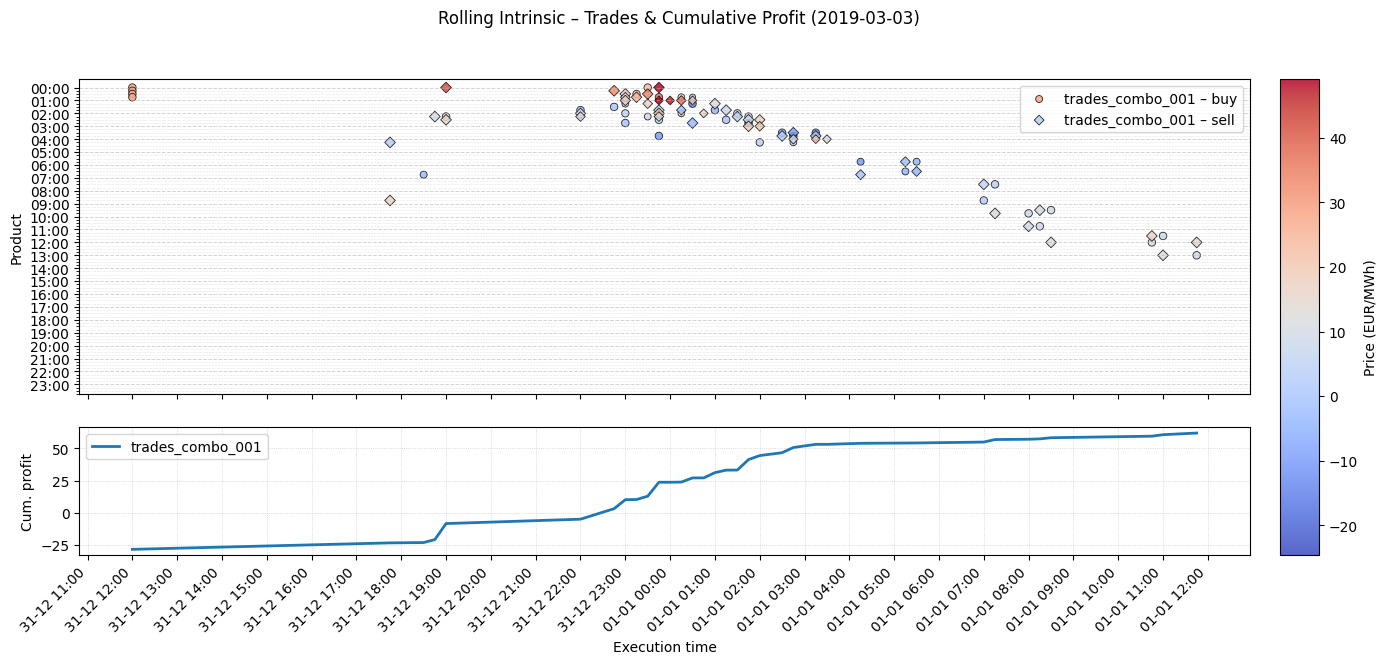

In [51]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# name plot
name = "ri_trades_profit_prices"
# ---------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------
def _prep_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["execution_time"] = pd.to_datetime(df["execution_time"])
    df["product"] = pd.to_datetime(df["product"])

    # Product → 15-min slots (0..95)
    df["prod_min"] = df["product"].dt.hour * 60 + df["product"].dt.minute
    df["prod_slot_15m"] = (df["prod_min"] // 15).astype(int)

    df["side"] = df["side"].str.lower().str.strip()
    df = df[df["side"].isin(["buy", "sell"])]

    df["quantity"] = df["quantity"].astype(float)
    df["price"] = df["price"].astype(float)
    df["profit"] = df["profit"].astype(float)

    # numerical noise cleanup
    df.loc[df["quantity"].abs() < 1e-10, "quantity"] = 0.0

    return df


# ---------------------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------------------
def plot_ri_trades_with_cum_profit(
    csv_paths: Sequence[str | Path],
    title: Optional[str] = None,
    size_by_quantity: bool = True,
    quantity_size_scale: float = 10.0,
    alpha: float = 0.85,
):
    csv_paths = [Path(p) for p in csv_paths]
    if not csv_paths:
        raise ValueError("csv_paths is empty")

    # --- Load data ---
    dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)
        df = _prep_trades(df)
        df["run"] = p.stem
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # shared color scale
    vmin, vmax = df_all["price"].min(), df_all["price"].max()

    # --- Figure layout (scatter | profit + external colorbar) ---
    fig = plt.figure(figsize=(16, 7))
    gs = GridSpec(
        2, 2,
        width_ratios=[30, 1],
        height_ratios=[3.2, 1.3],
        wspace=0.05,
        hspace=0.15,
    )

    ax_scatter = fig.add_subplot(gs[0, 0])
    ax_profit = fig.add_subplot(gs[1, 0], sharex=ax_scatter)
    cax = fig.add_subplot(gs[:, 1])

    marker_map = {"buy": "o", "sell": "D"}

    def _sizes(q: np.ndarray) -> np.ndarray:
        if not size_by_quantity:
            return np.full_like(q, 60.0)
        qabs = np.abs(q)
        return 20.0 + quantity_size_scale * np.sqrt(qabs / (qabs.max() + 1e-12))

    # -----------------------------------------------------------------
    # Scatter + Cum Profit (overlay runs if multiple CSVs given)
    # -----------------------------------------------------------------
    mappable = None
    for run in sorted(df_all["run"].unique()):
        df_run = df_all[df_all["run"] == run]

        # --- Scatter ---
        for side in ["buy", "sell"]:
            d = df_run[df_run["side"] == side]
            if d.empty:
                continue

            sc = ax_scatter.scatter(
                d["execution_time"],
                d["prod_slot_15m"],
                c=d["price"],
                cmap="coolwarm",
                vmin=vmin,
                vmax=vmax,
                s=_sizes(d["quantity"].to_numpy()),
                marker=marker_map[side],
                alpha=alpha,
                edgecolors="black",
                linewidths=0.6,
                label=f"{run} – {side}",
            )
            mappable = sc

        # --- Cumulated profit ---
        prof = (
            df_run.groupby("execution_time", as_index=False)["profit"]
            .sum()
            .sort_values("execution_time")
        )
        prof["cum_profit"] = prof["profit"].cumsum()

        ax_profit.plot(
            prof["execution_time"],
            prof["cum_profit"],
            linewidth=2.0,
            label=run,
        )

    # -----------------------------------------------------------------
    # Formatting: Scatter
    # -----------------------------------------------------------------
    ax_scatter.set_ylabel("Product")

    hour_slots = np.arange(0, 96, 4)
    ax_scatter.set_yticks(hour_slots)
    ax_scatter.set_yticklabels([f"{h//4:02d}:00" for h in hour_slots])

    ax_scatter.set_yticks(np.arange(0, 96), minor=True)
    ax_scatter.grid(which="minor", axis="y", linestyle="--", linewidth=0.4, alpha=0.35)
    ax_scatter.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.55)

    ax_scatter.invert_yaxis()
    ax_scatter.legend(loc="upper right")

    # -----------------------------------------------------------------
    # Formatting: Profit
    # -----------------------------------------------------------------
    ax_profit.set_ylabel("Cum. profit")
    ax_profit.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    ax_profit.legend(loc="upper left")

    # -----------------------------------------------------------------
    # Shared X axis (HOURLY ticks like first version)
    # -----------------------------------------------------------------
    ax_profit.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax_profit.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
    ax_profit.set_xlabel("Execution time")

    fig.autofmt_xdate(rotation=45, ha="right")

    # -----------------------------------------------------------------
    # Colorbar (external, clean)
    # -----------------------------------------------------------------
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label("Price (EUR/MWh)")

    if title:
        fig.suptitle(title, y=0.98)

    fig.tight_layout()
    return fig, (ax_scatter, ax_profit)


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
if __name__ == "__main__":
    plot_ri_trades_with_cum_profit(
        csv_paths=[
            "results/trades/2019-01-01/trades_combo_001.csv",
            #"results/trades/2019-03-03/trades_combo_279.csv",
        ],
        title="Rolling Intrinsic – Trades & Cumulative Profit (2019-03-03)",
    )

    filepath = os.path.join(folder, f"{name}.png")
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()


#### Profits daily distributions absolut profit

In [58]:
df.columns

Index(['day', 'combo_id', 'kind', 'buy_hour', 'sell_hour', 'profit',
       'da_exec_time', 'da_profit', 'da_buy_price', 'da_sell_price',
       'da_profit_share', 'RI_base', 'uplift_ri_base_abs',
       'uplift_ri_base_pct', 'myopic_base', 'uplift_myopic_abs',
       'uplift_myopic_pct'],
      dtype='object')

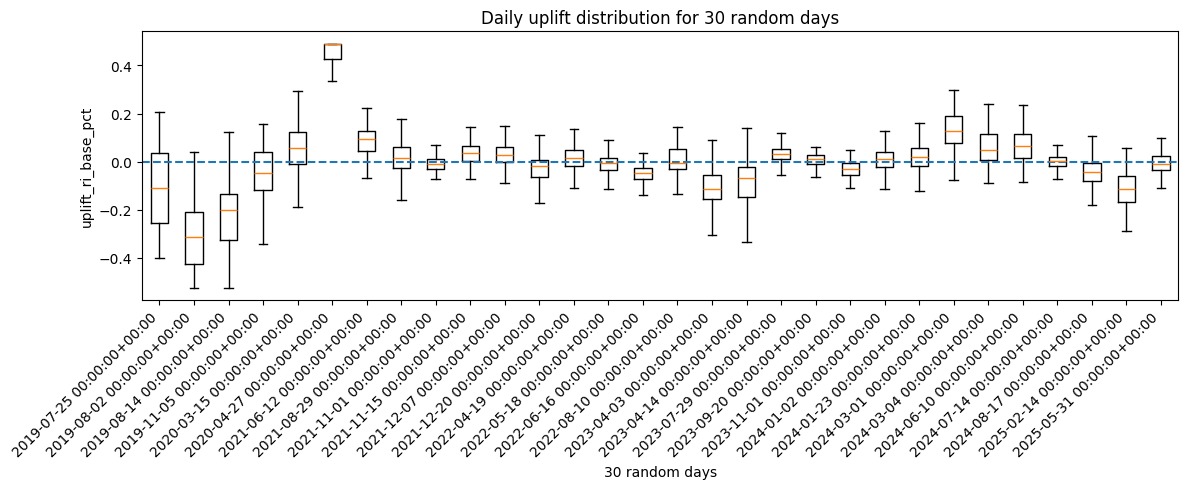

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_for_30_random_days(
    df: pd.DataFrame,
    date_col: str = "day",
    value_col: str = "uplift_ri_base_pct",
    n_days: int = 30,
    sort_days: str = "day",   # "day", "median" oder "mean"
    showfliers: bool = False,
    random_state: int = 42,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Alle verfügbaren Tage
    all_days = d[date_col].drop_duplicates().tolist()

    # Falls weniger als 30 Tage vorhanden sind, nimm alle
    n_days = min(n_days, len(all_days))

    # 30 zufällige Tage ziehen
    rng = np.random.default_rng(random_state)
    sampled_days = rng.choice(all_days, size=n_days, replace=False).tolist()

    # Optional sortieren
    if sort_days == "median":
        day_order = (
            d[d[date_col].isin(sampled_days)]
            .groupby(date_col)[value_col]
            .median()
            .sort_values(ascending=True)
            .index.tolist()
        )
    elif sort_days == "mean":
        day_order = (
            d[d[date_col].isin(sampled_days)]
            .groupby(date_col)[value_col]
            .mean()
            .sort_values(ascending=True)
            .index.tolist()
        )
    else:
        # nach Datum sortieren
        day_order = sorted(sampled_days)

    # Daten pro Tag vorbereiten
    grouped = {
        day: d.loc[d[date_col] == day, value_col].values
        for day in day_order
    }

    data = [grouped[day] for day in day_order]

    # Ein einzelner Plot
    plt.figure(figsize=(max(12, len(day_order) * 0.4), 5))
    plt.boxplot(data, showfliers=showfliers)

    # Baseline-Linie
    plt.axhline(0, linestyle="--")

    # Alle 30 Tage auf der X-Achse anzeigen
    plt.xticks(
        ticks=np.arange(1, len(day_order) + 1),
        labels=[str(day) for day in day_order],
        rotation=45,
        ha="right"
    )

    plt.xlabel("30 random days")
    plt.ylabel(value_col)
    plt.title(f"Daily uplift distribution for {len(day_order)} random days")
    plt.tight_layout()
    plt.show()


# Optional: Werte clippen
q01, q99 = df["uplift_ri_base_pct"].quantile([0.01, 0.99])
df["uplift_ri_base_pct"] = df["uplift_ri_base_pct"].clip(q01, q99)

# Aufruf
plot_boxplots_for_30_random_days(
    df,
    date_col="day",
    value_col="uplift_ri_base_pct",
    n_days=30,
    sort_days="day",
    showfliers=False,
    random_state=42
)

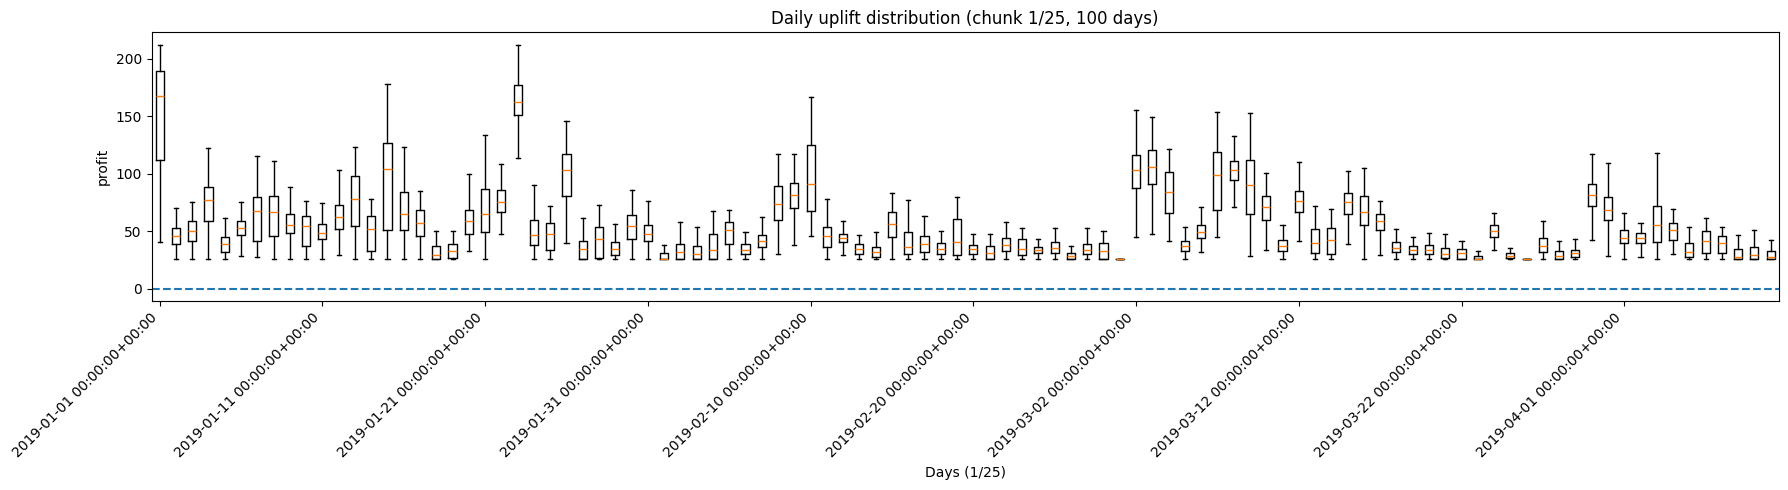

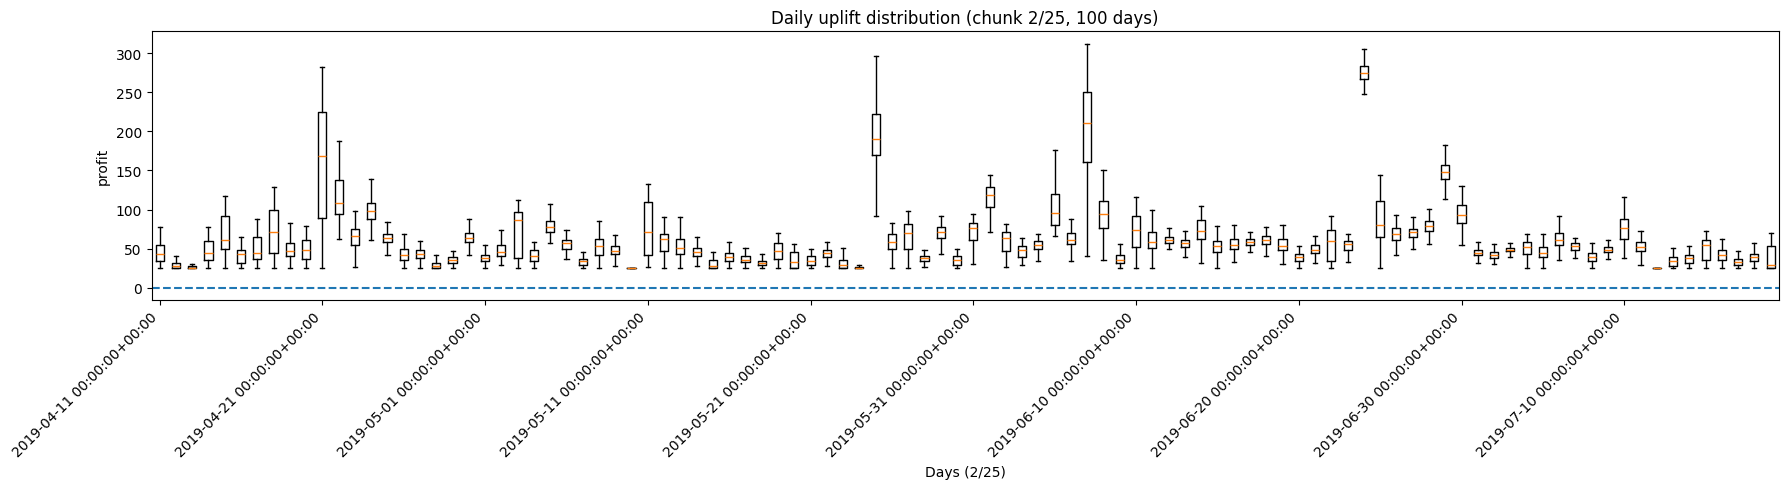

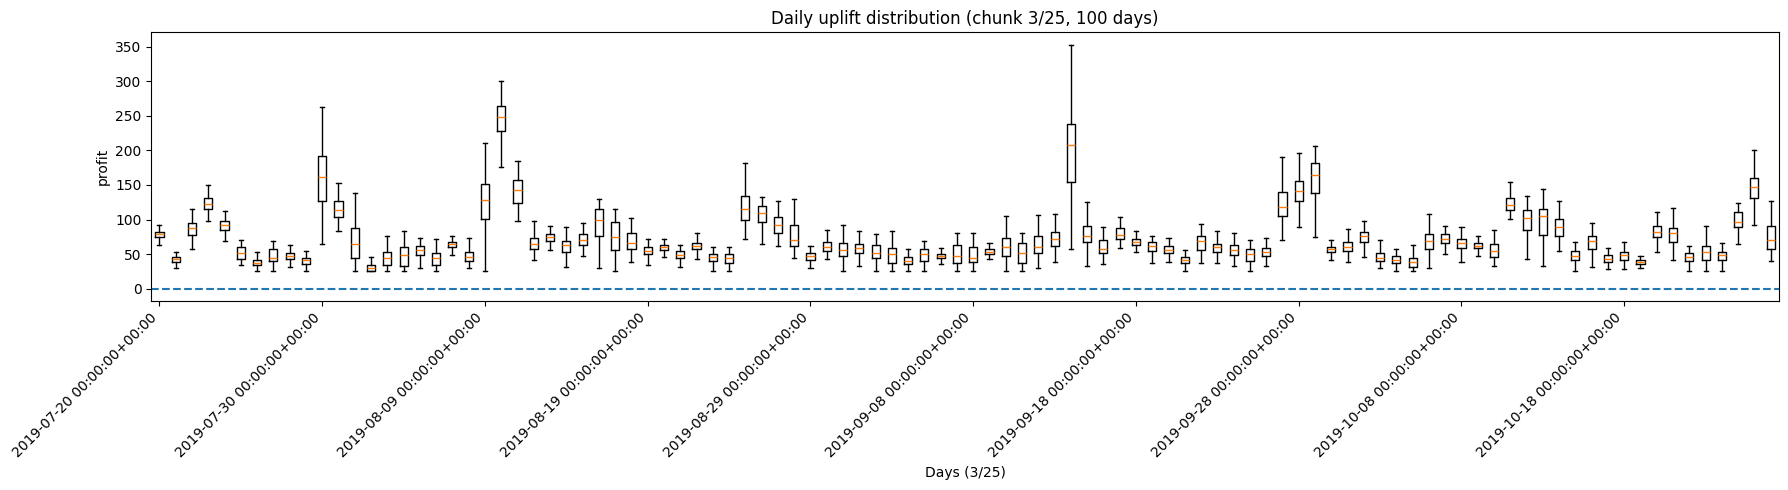

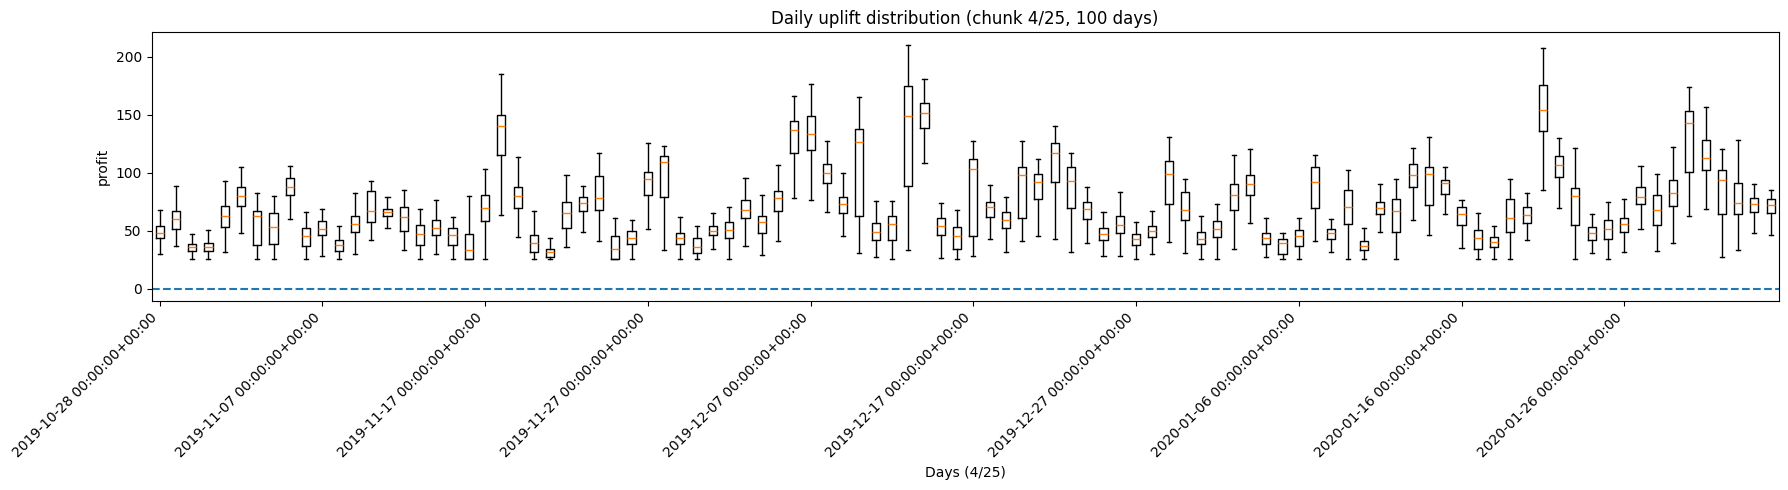

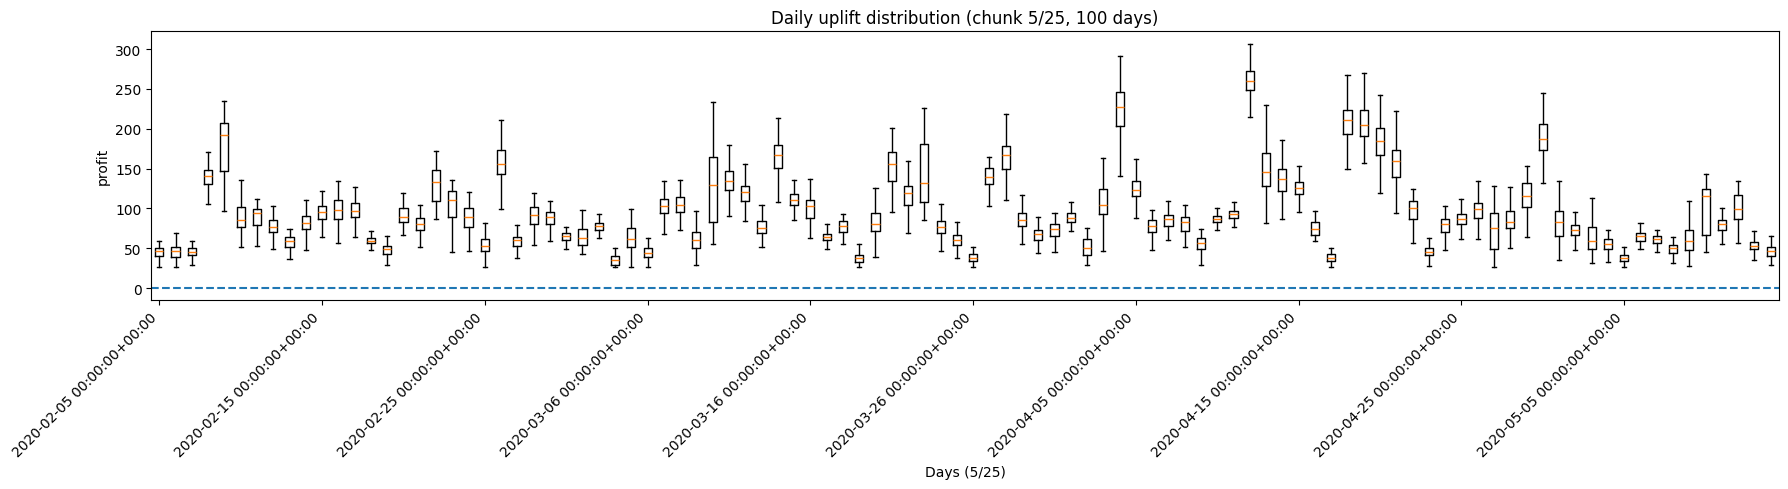

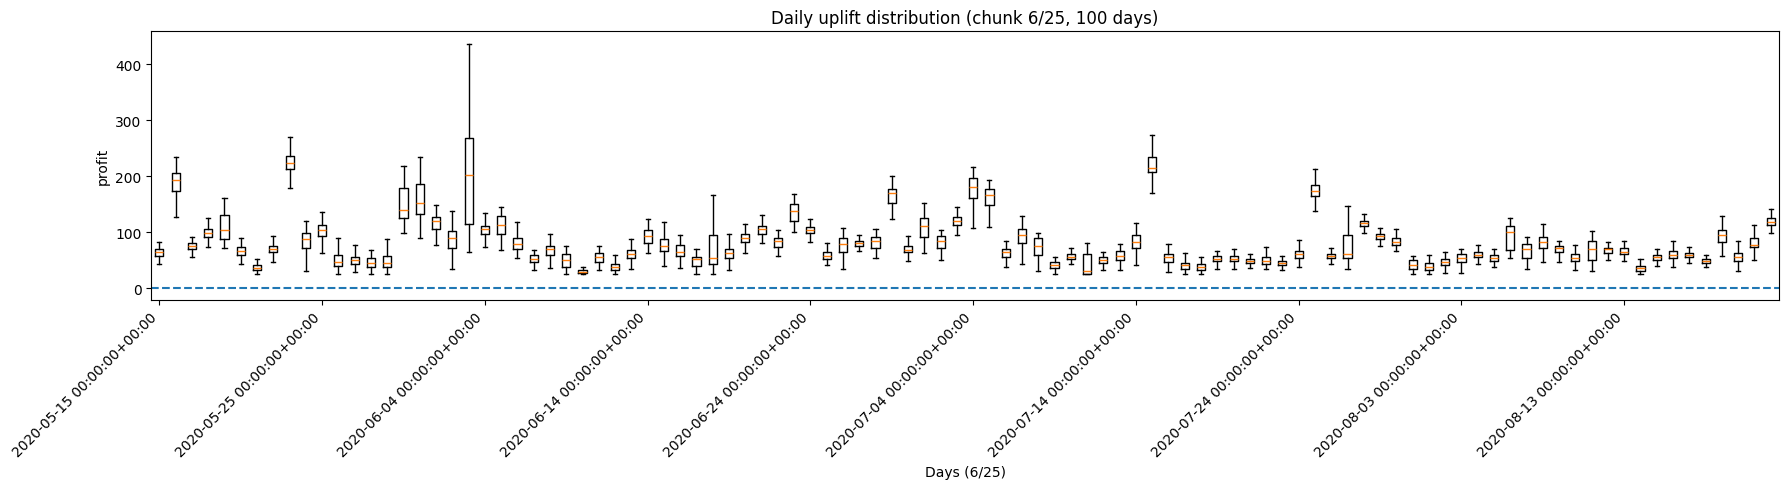

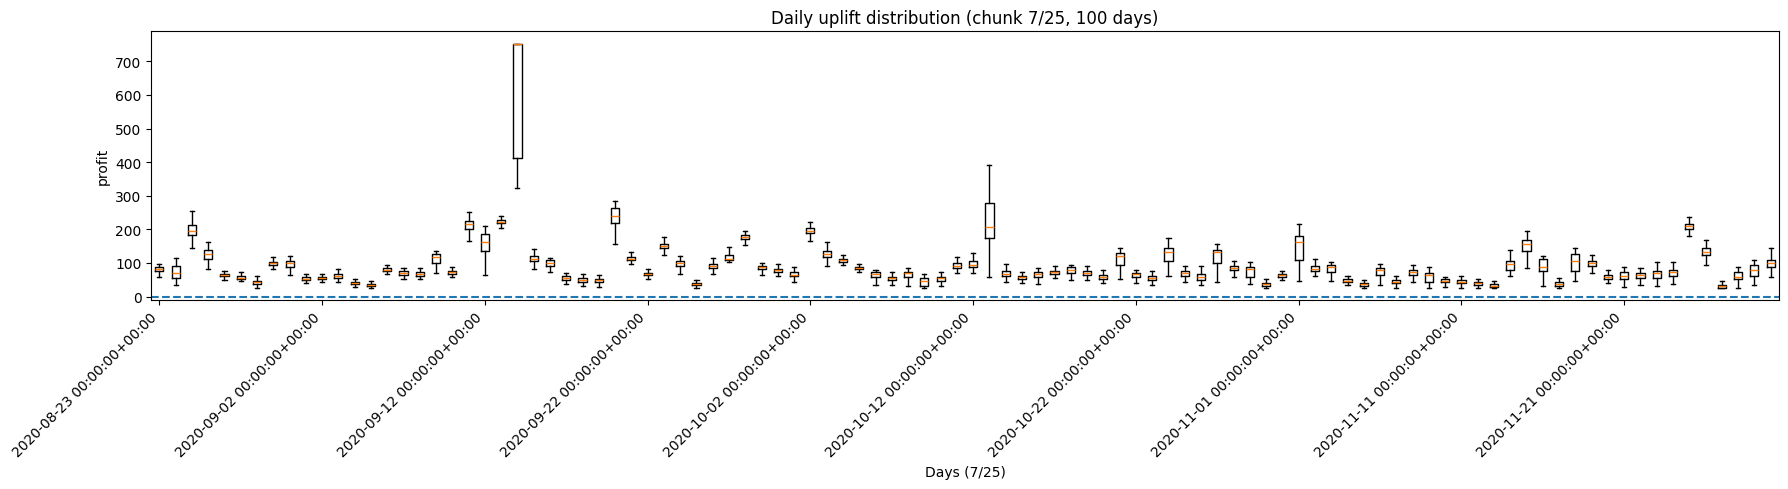

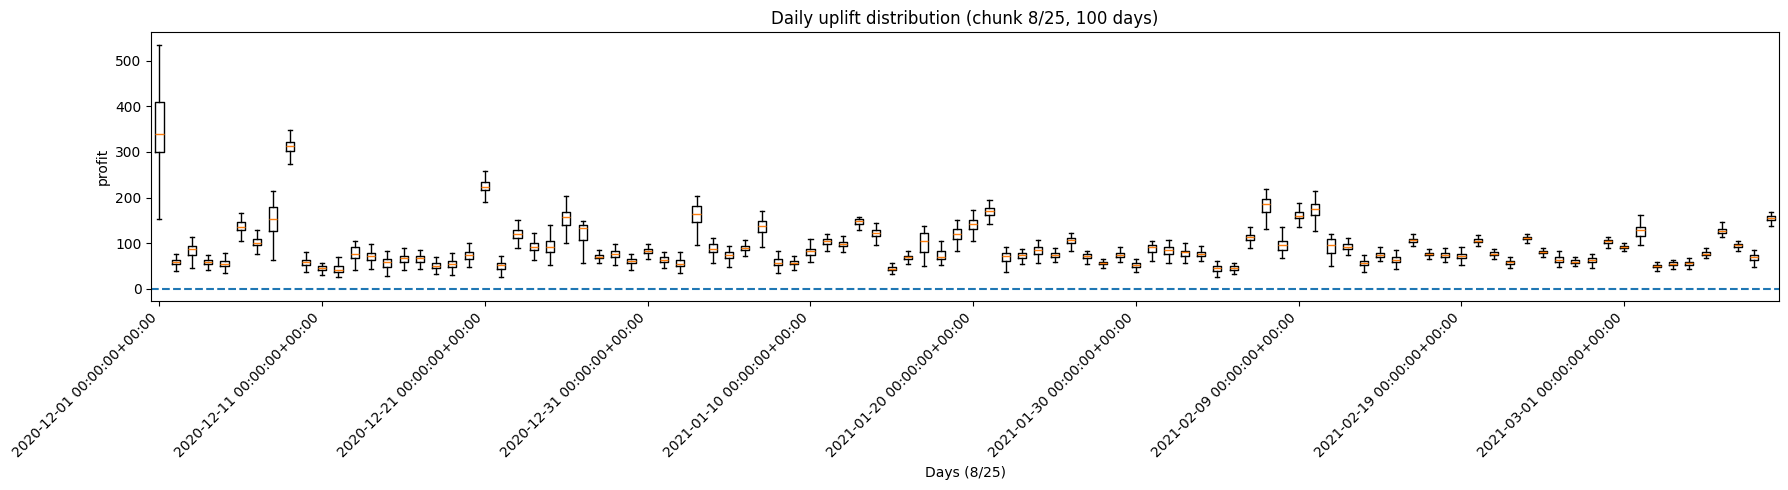

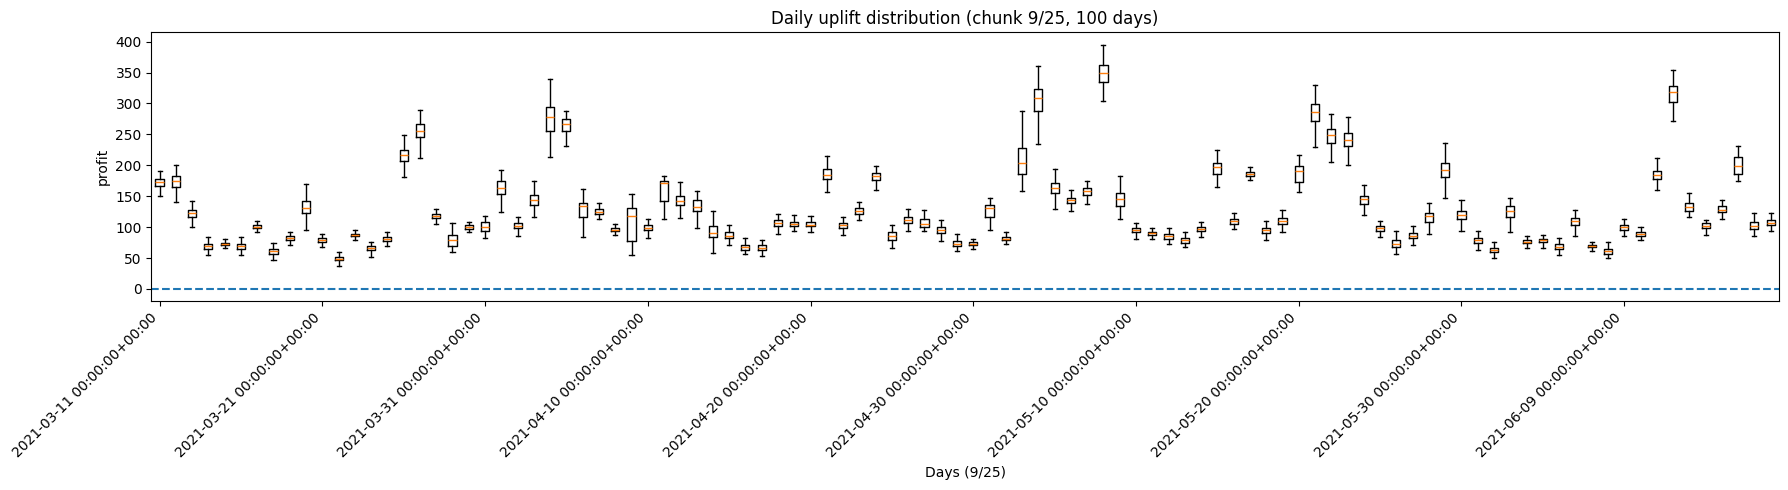

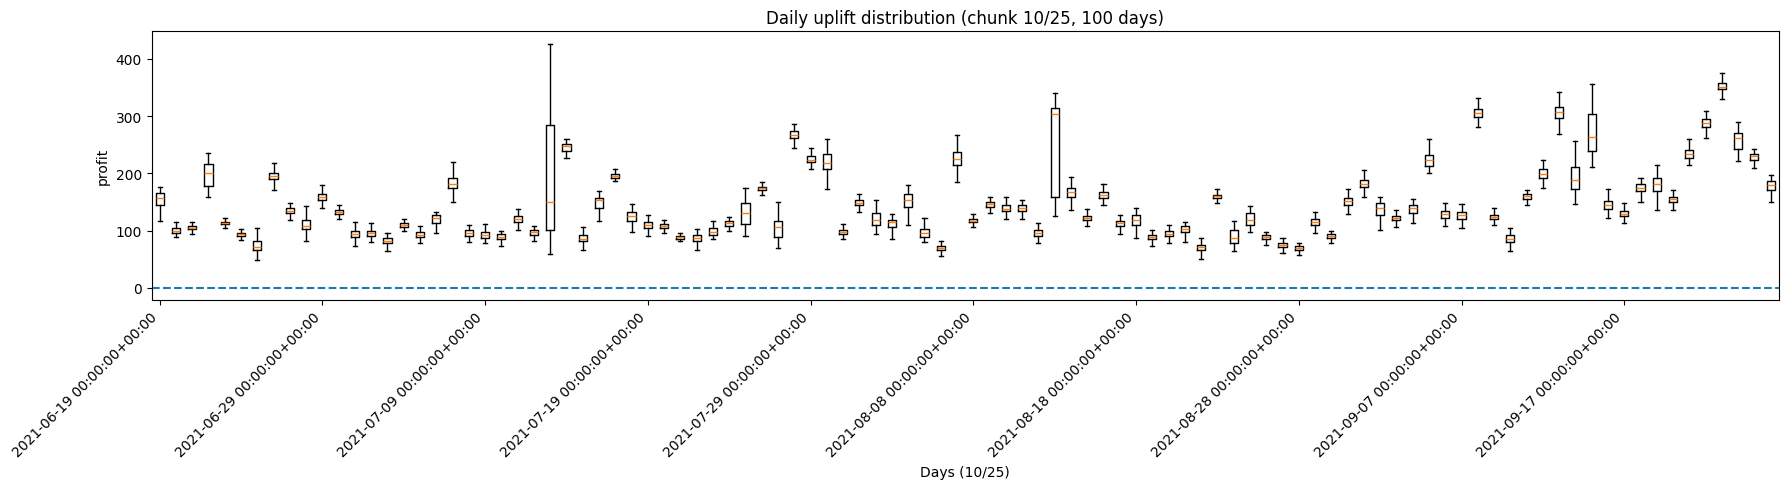

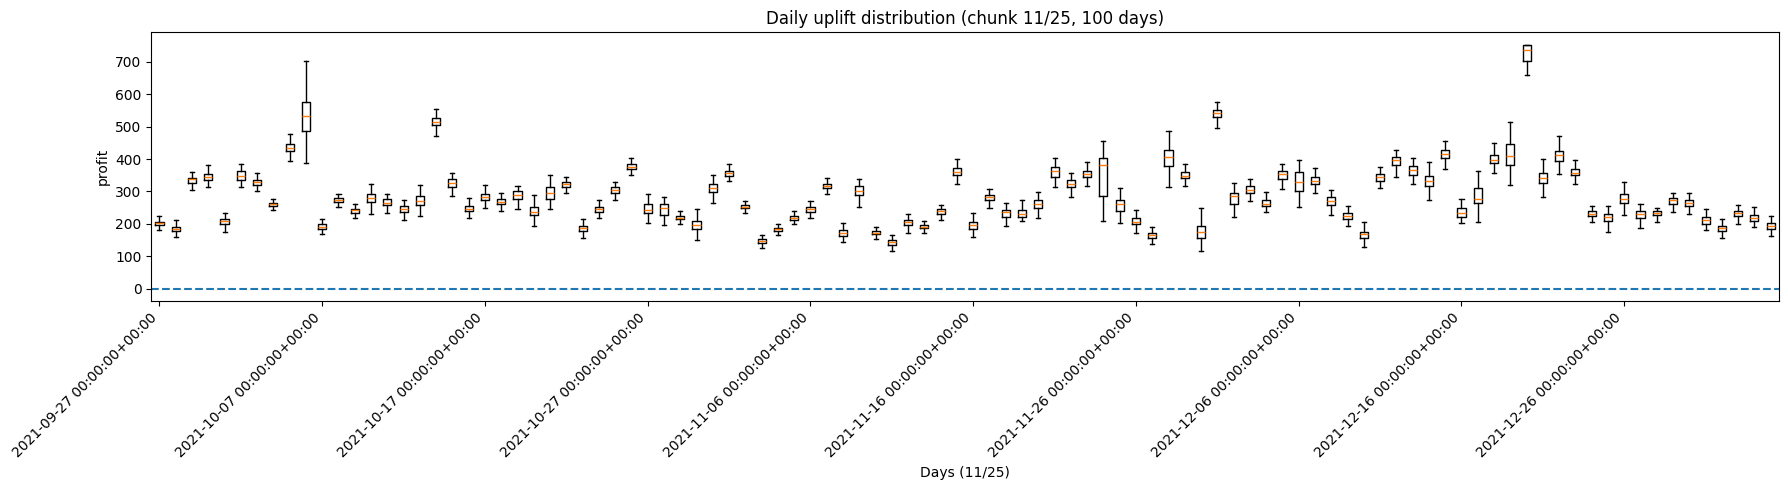

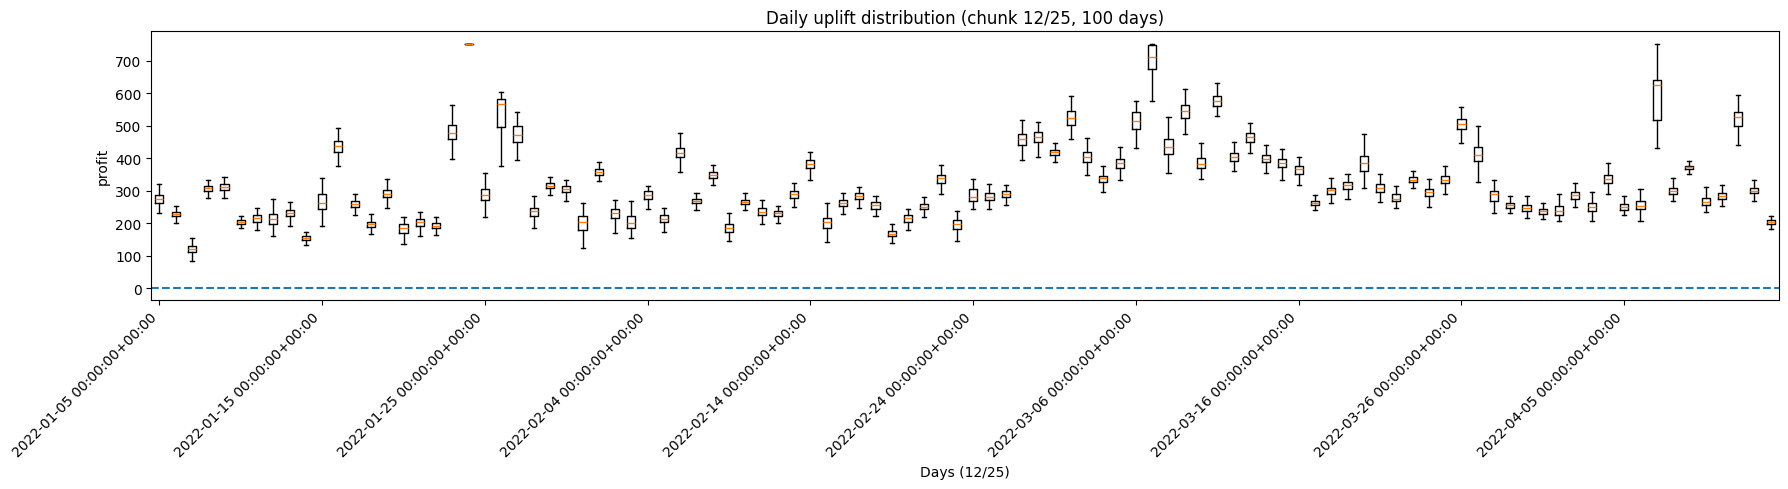

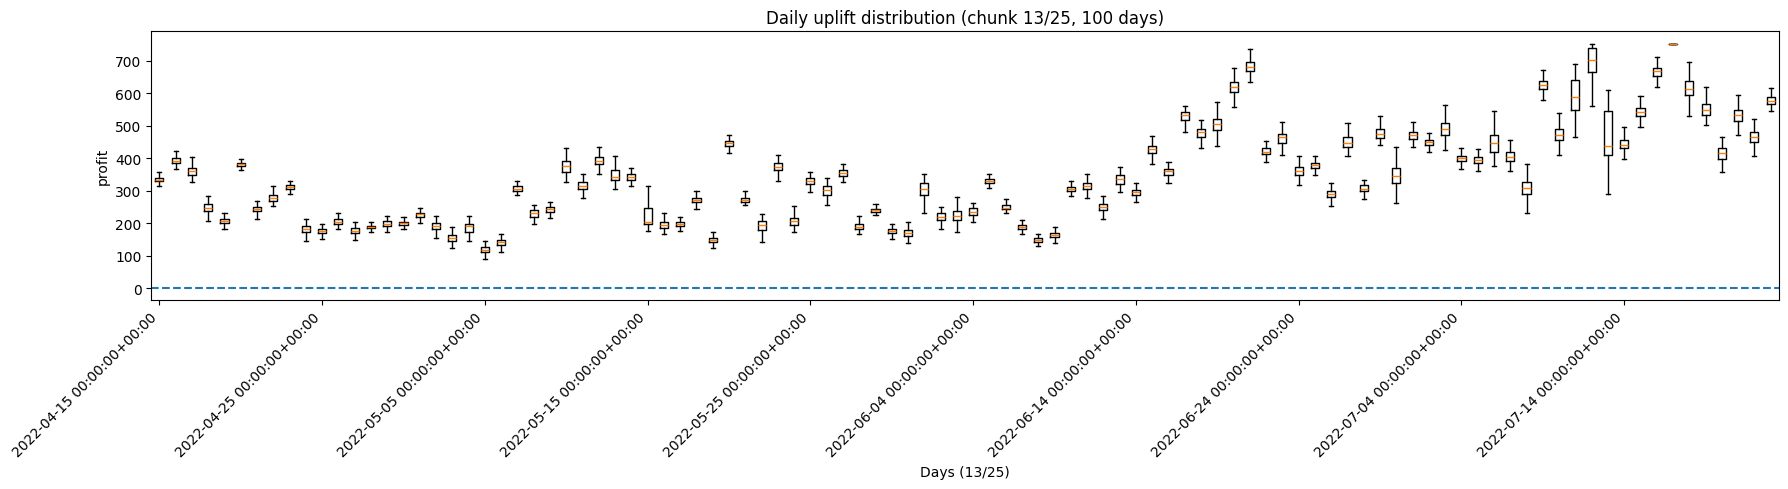

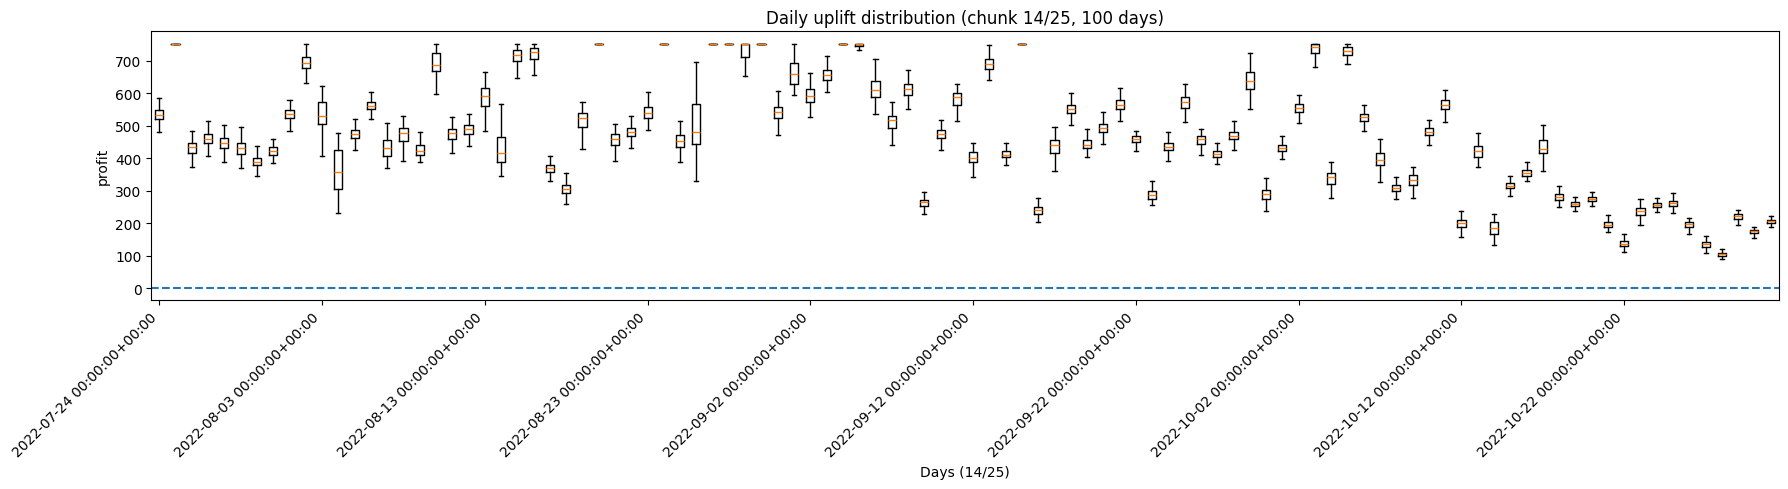

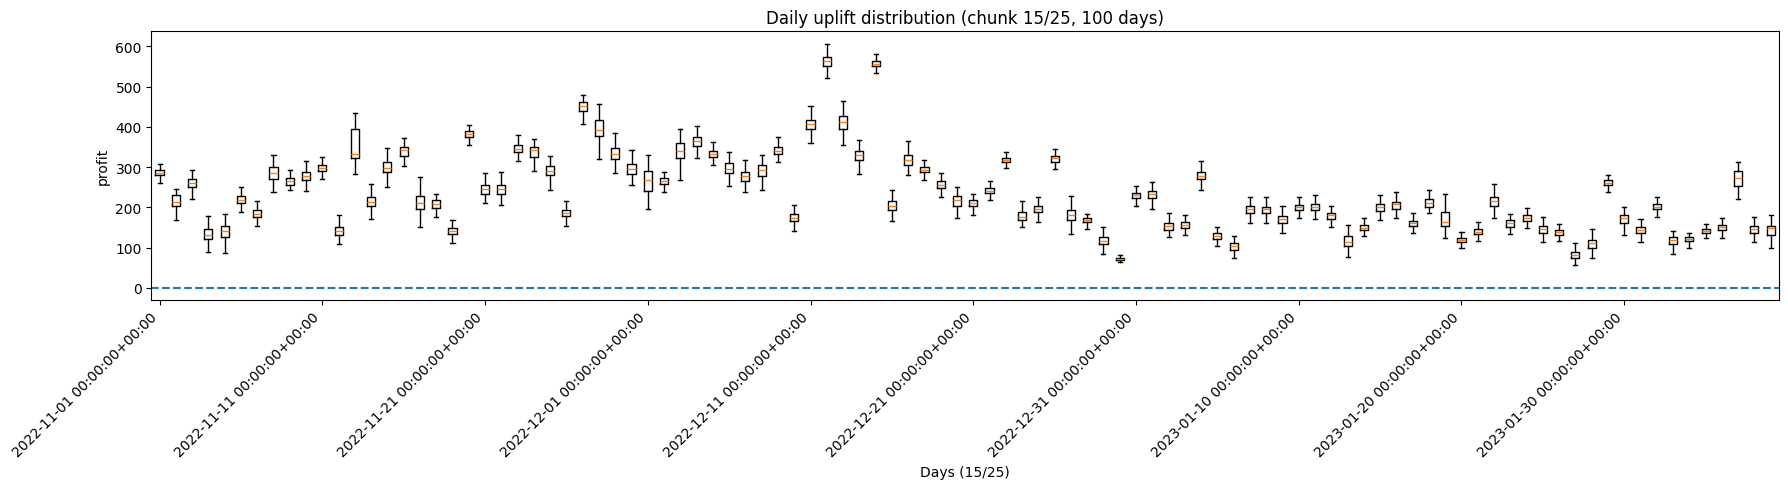

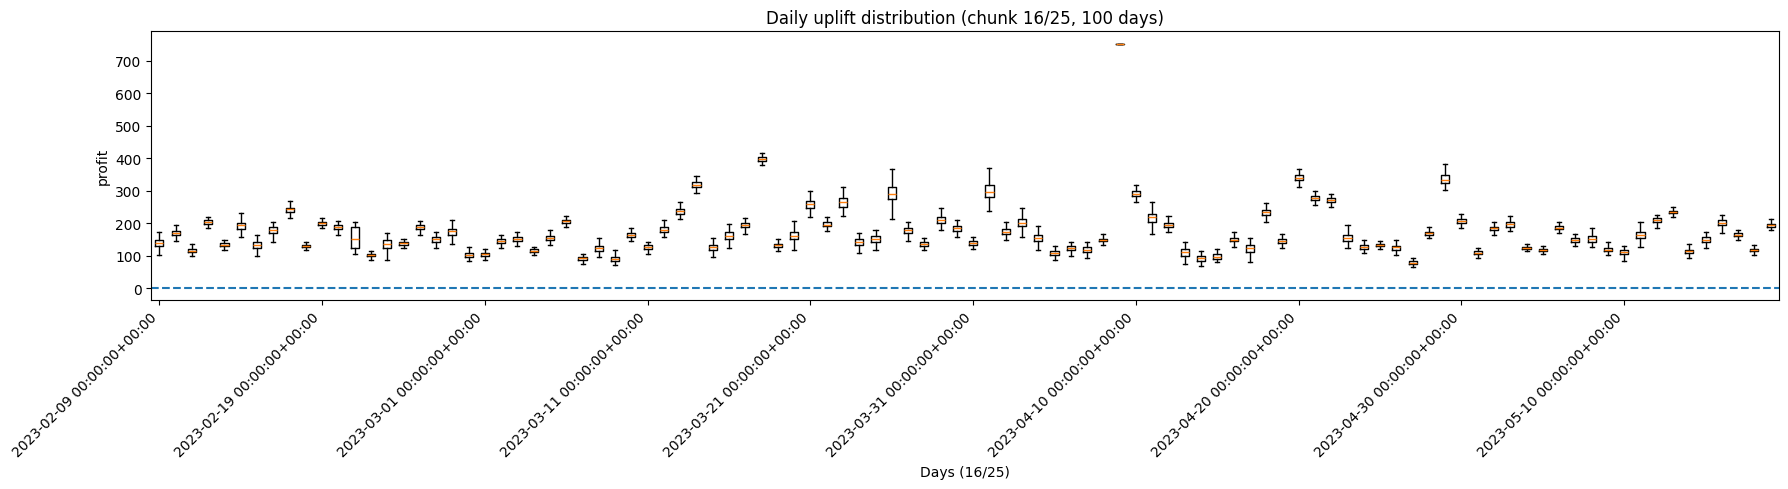

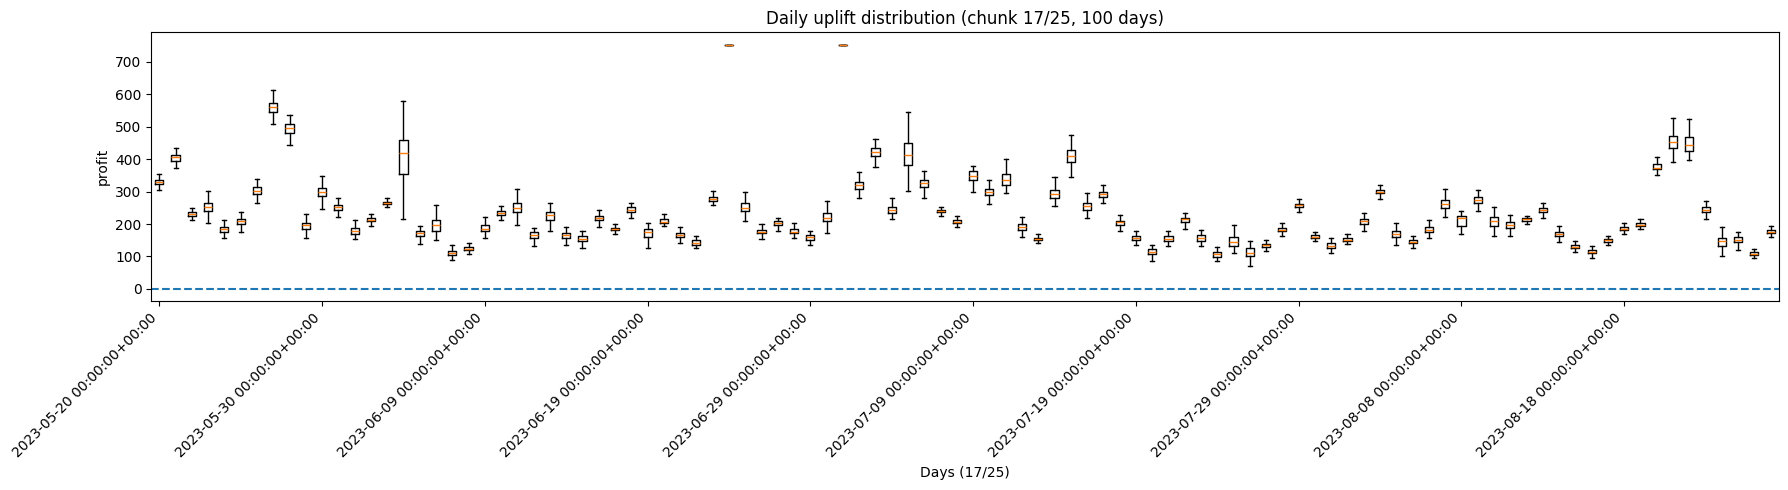

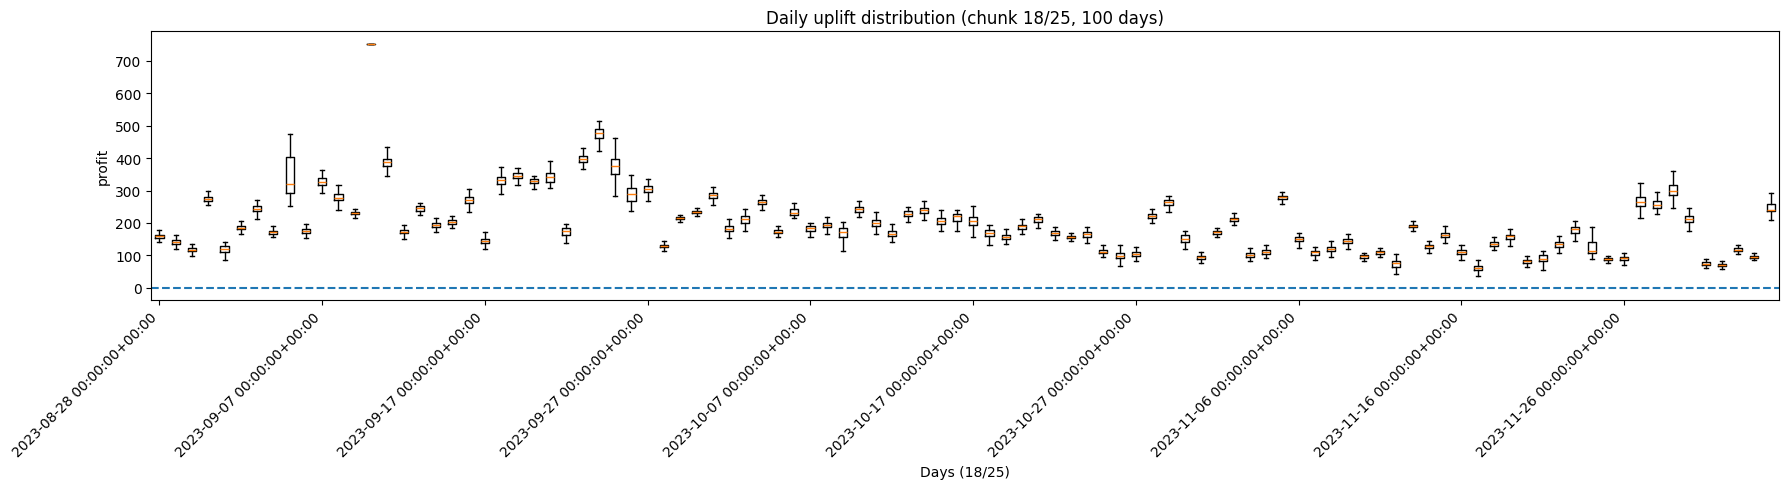

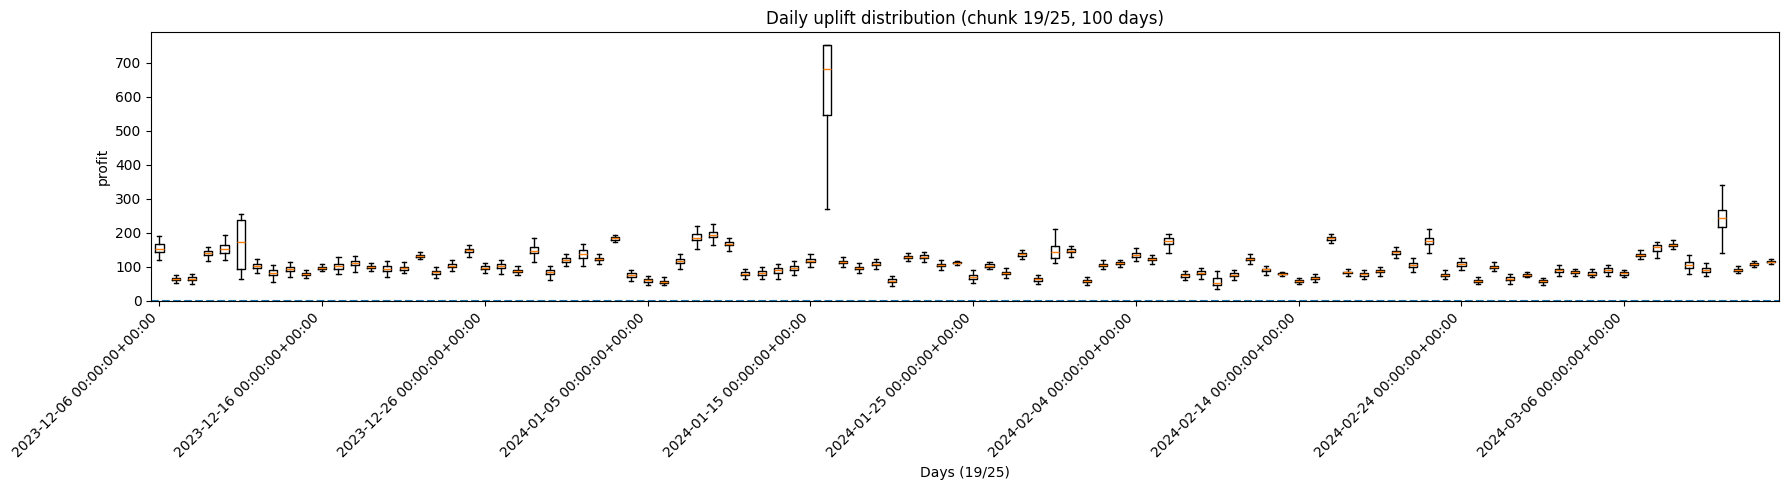

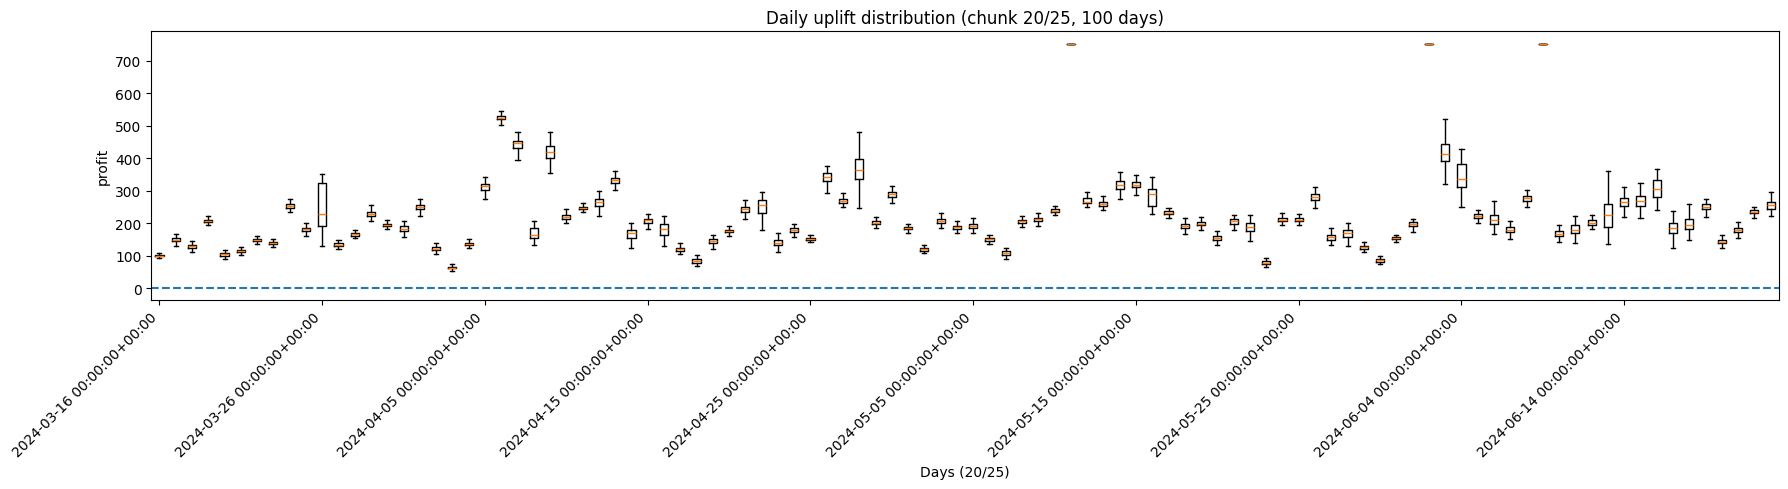

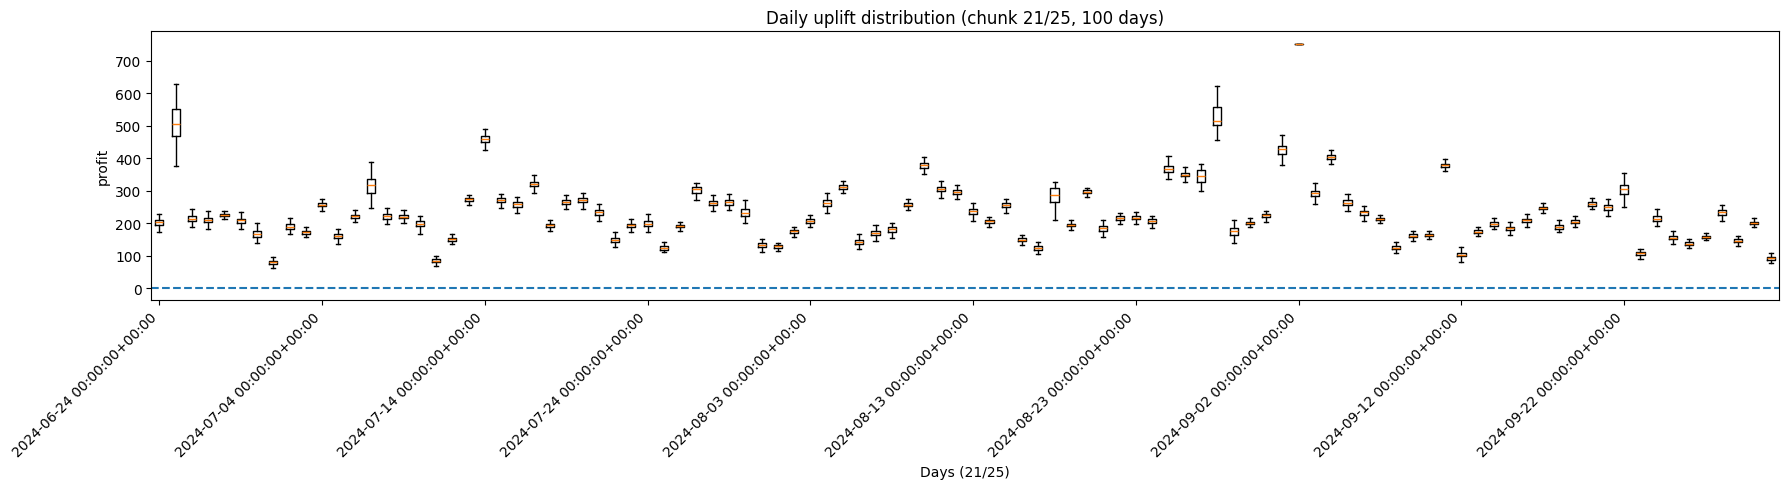

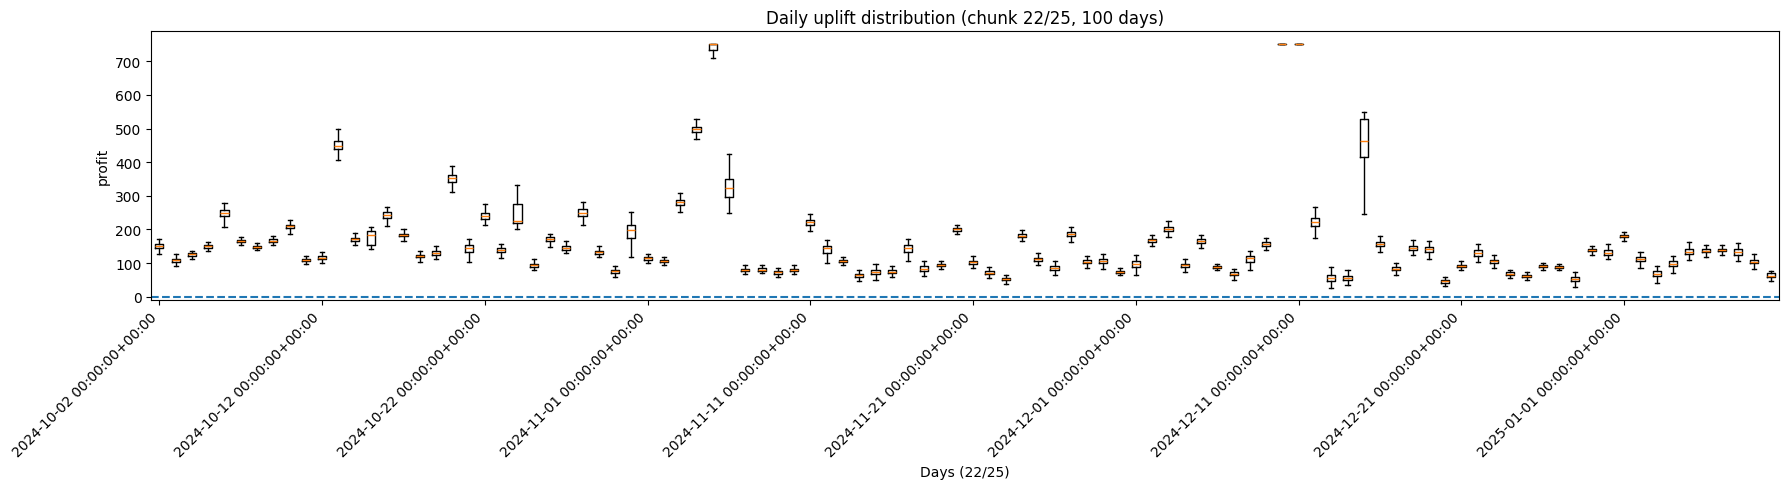

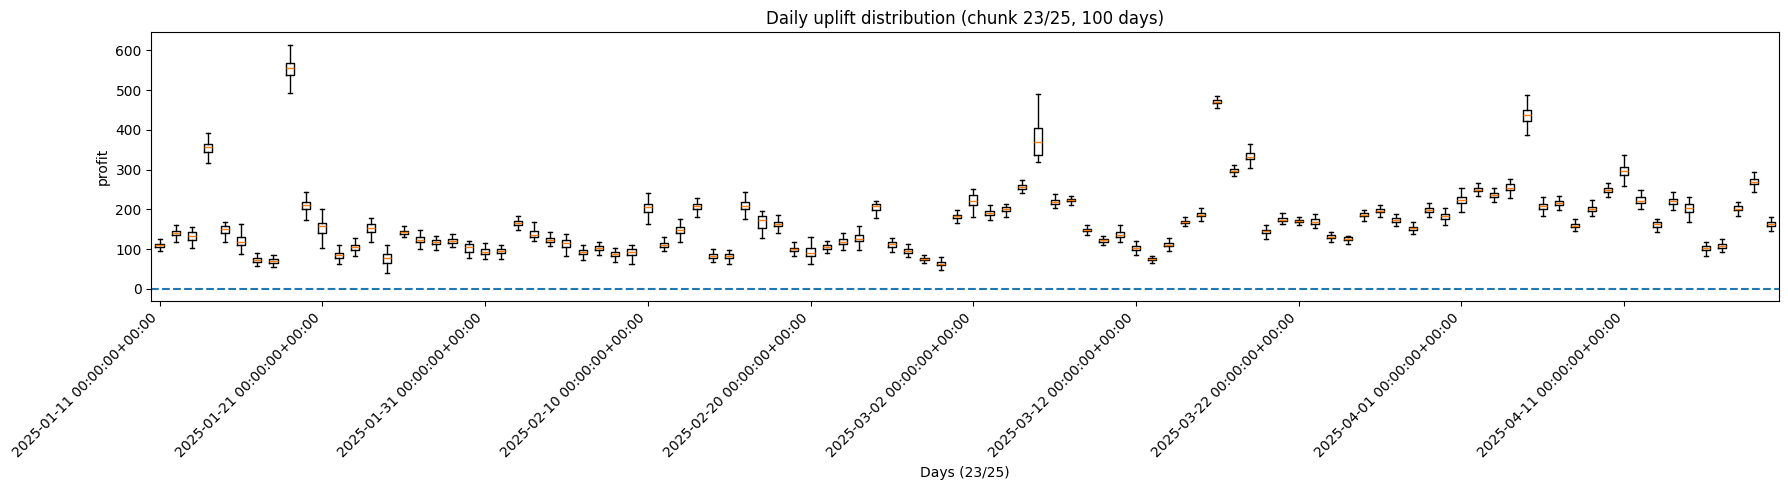

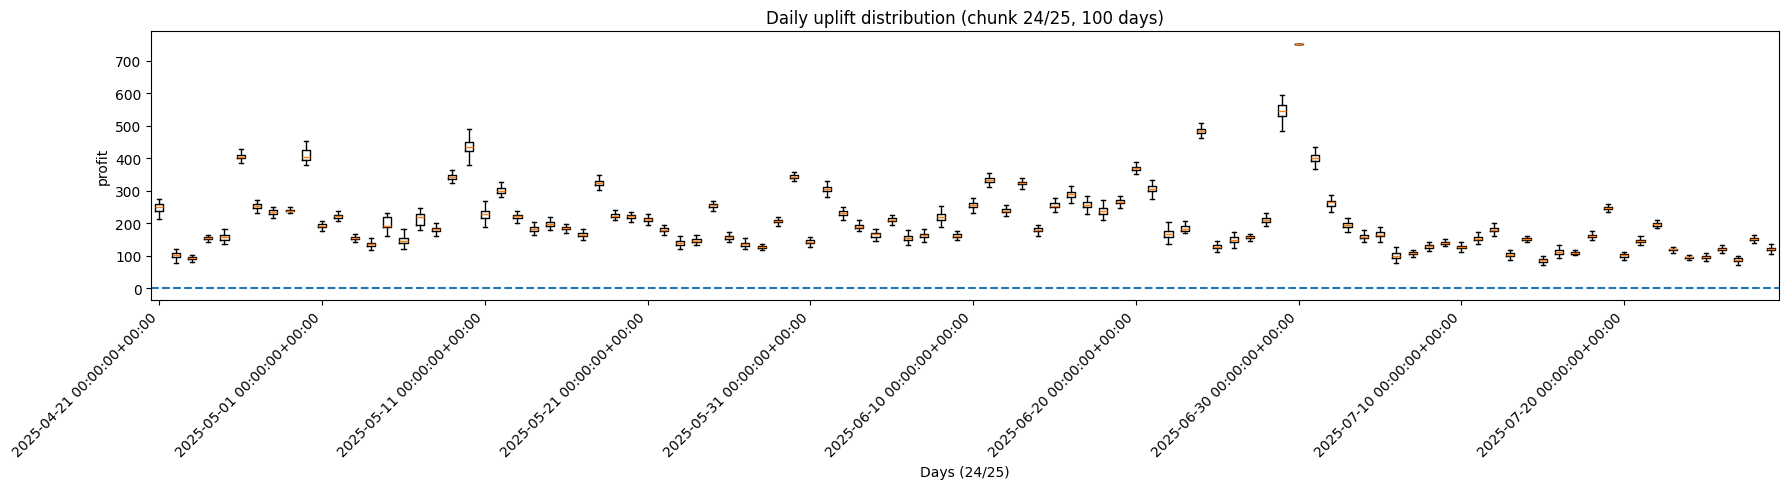

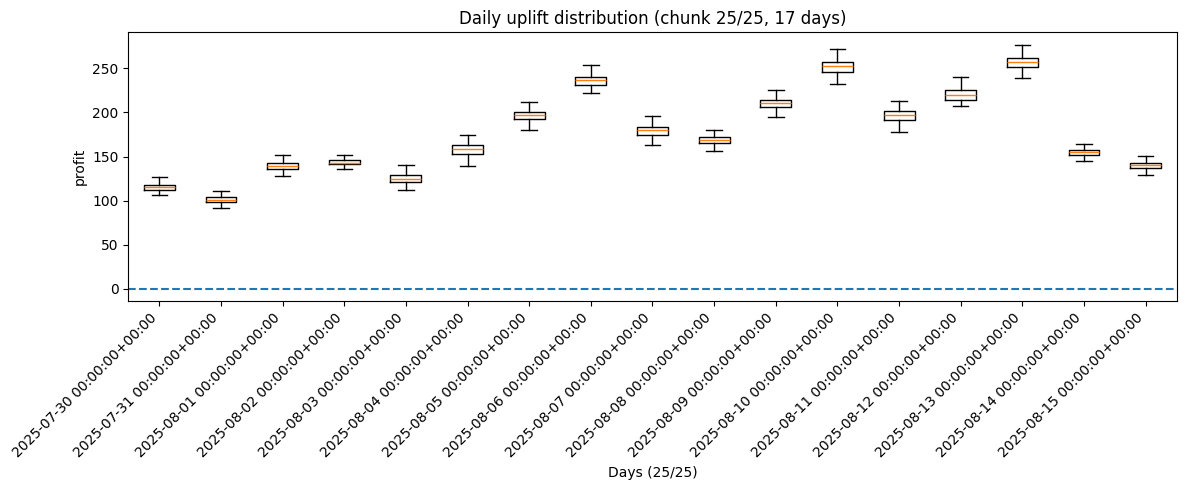

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_by_day_chunks(
    df: pd.DataFrame,
    date_col: str = "date",
    value_col: str = "profit",
    chunk_size: int = 80,
    sort_days: str = "day",   # "date" oder "median" oder "mean"
    showfliers: bool = False,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Liste aller Tage
    days = d[date_col].drop_duplicates()

    # Sortierung (optional hilfreich)
    if sort_days == "median":
        day_order = (d.groupby(date_col)[value_col].median()
                       .sort_values(ascending=True).index.tolist())
    elif sort_days == "mean":
        day_order = (d.groupby(date_col)[value_col].mean()
                       .sort_values(ascending=True).index.tolist())
    else:
        # nach Datum (sicher, wenn date echtes Date/Datetime ist)
        day_order = sorted(days.tolist())

    # Daten pro Tag einmal vorbereiten (spart Zeit)
    grouped = {day: d.loc[d[date_col] == day, value_col].values for day in day_order}

    n = len(day_order)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in range(n_chunks):
        chunk_days = day_order[i*chunk_size:(i+1)*chunk_size]
        data = [grouped[day] for day in chunk_days]

        plt.figure(figsize=(max(12, len(chunk_days)*0.18), 5))
        plt.boxplot(data, showfliers=showfliers)

        # Baseline-Linie
        plt.axhline(0, linestyle="--")

        # X-Achse: nicht jeden Tag labeln (sonst zu voll)
        tick_step = max(1, len(chunk_days)//10)
        ticks = np.arange(1, len(chunk_days)+1, tick_step)
        labels = [str(chunk_days[t-1]) for t in ticks]

        plt.xticks(ticks, labels, rotation=45, ha="right")
        plt.xlabel(f"Days ({i+1}/{n_chunks})")
        plt.ylabel(value_col)
        plt.title(f"Daily uplift distribution (chunk {i+1}/{n_chunks}, {len(chunk_days)} days)")
        plt.tight_layout()
        plt.show()

#q01, q99 = df["uplift_pct"].quantile([0.01, 0.99])
#df["uplift_pct_plot"] = df["uplift_pct"].clip(q01, q99)

q01, q99 = df["profit"].quantile([0.01, 0.99])
df["profit"] = df["profit"].clip(q01, q99)
# Aufruf
plot_boxplots_by_day_chunks(
    df,
    date_col="day",
    value_col="profit",
    chunk_size=100,
    sort_days="day",
    showfliers=False
)

#### Profits daily distributions uplift to baseline RI

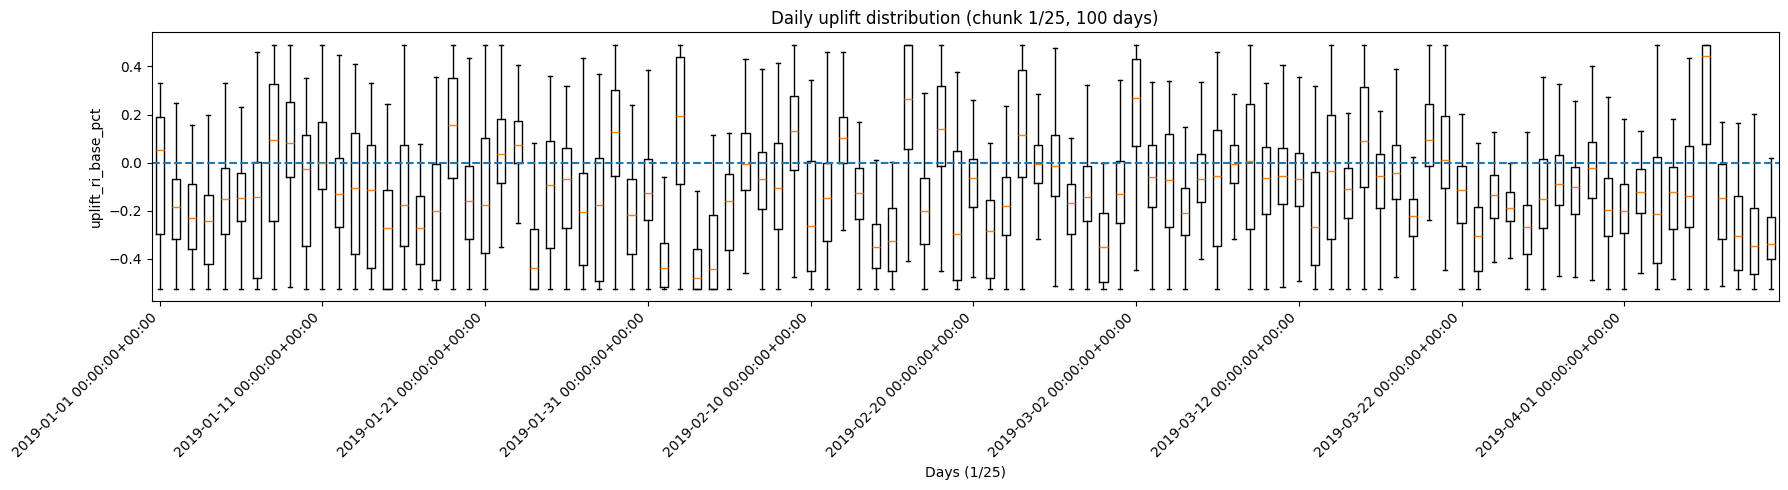

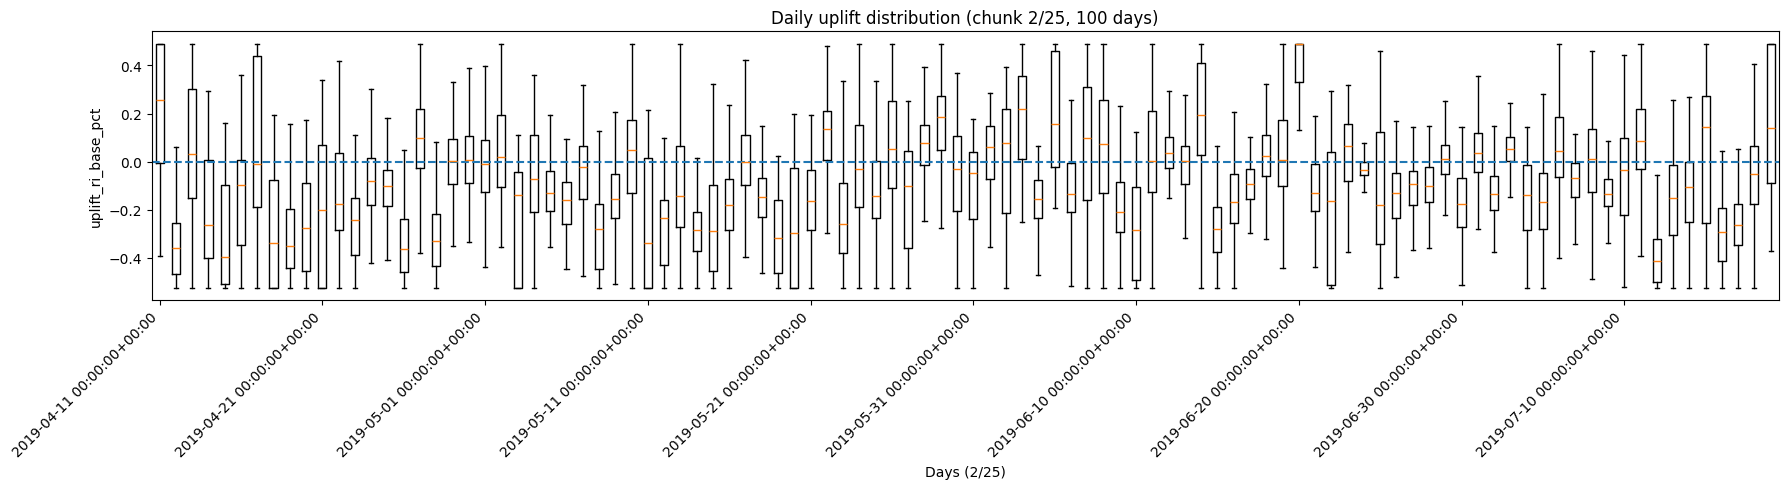

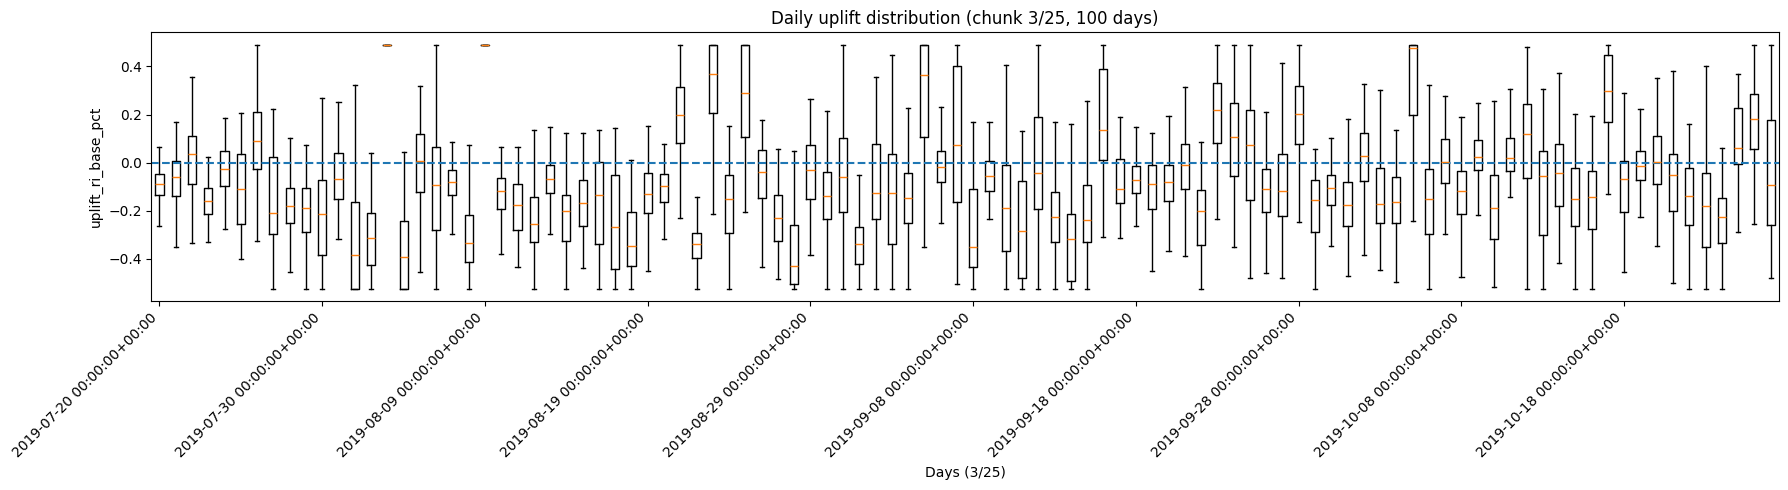

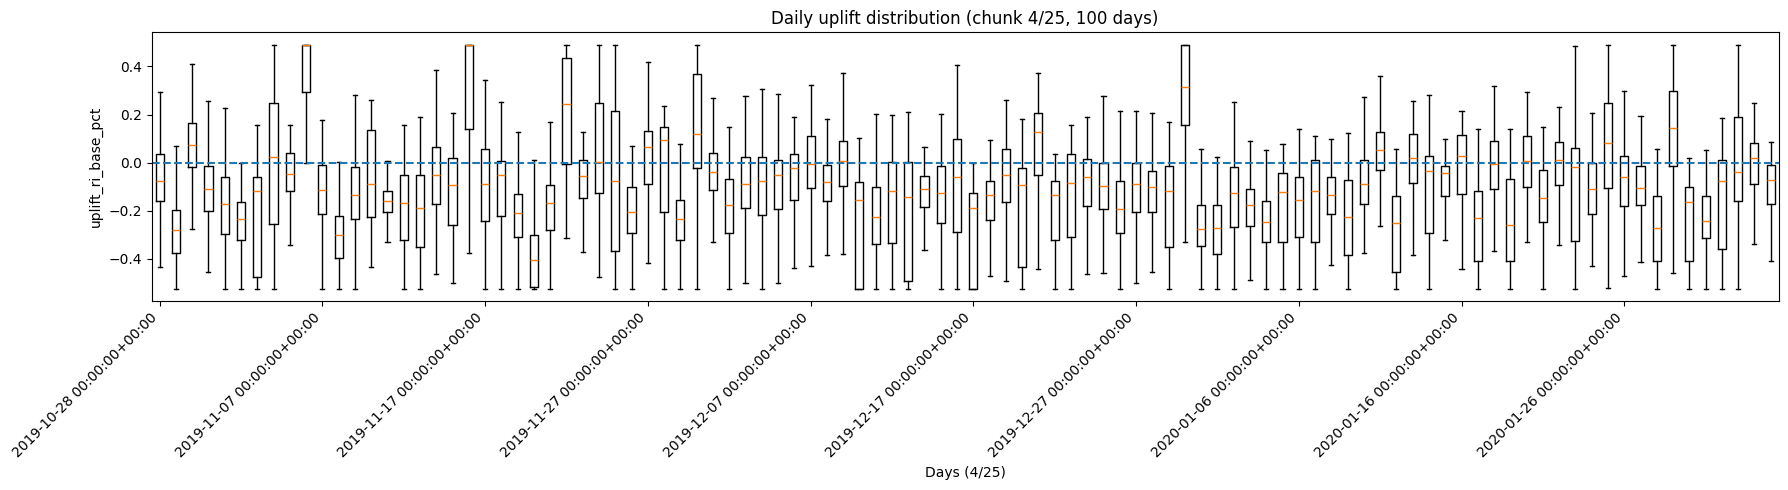

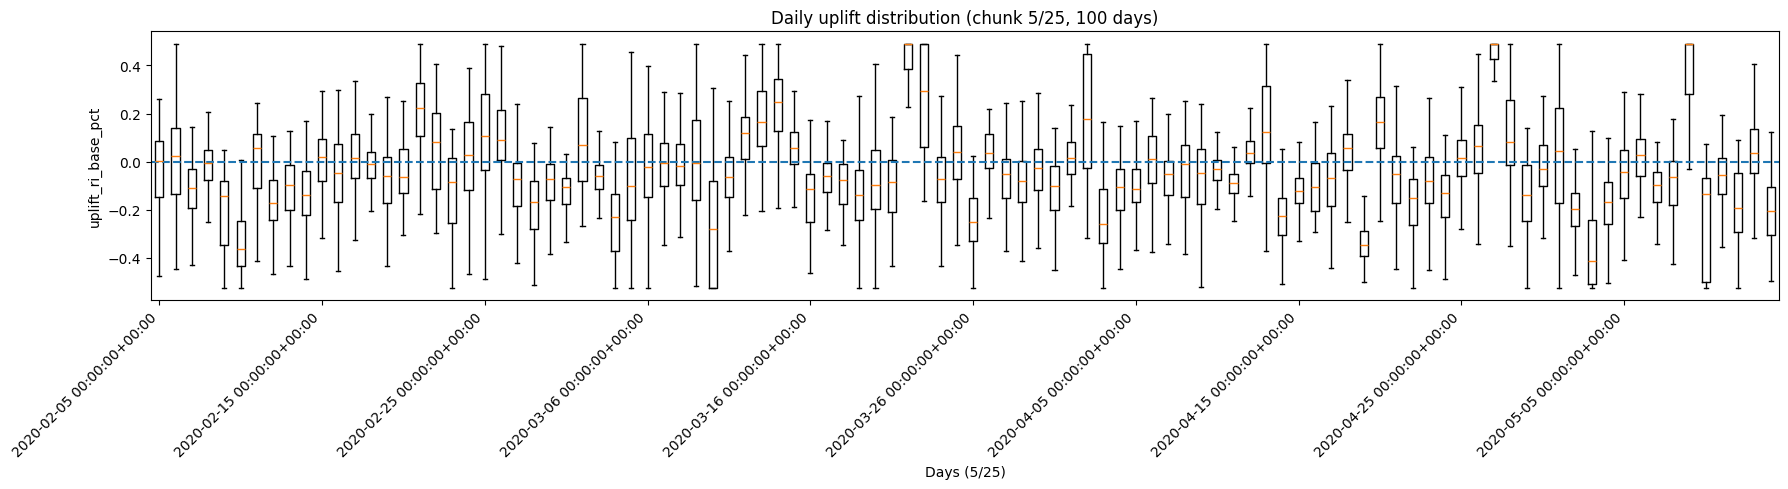

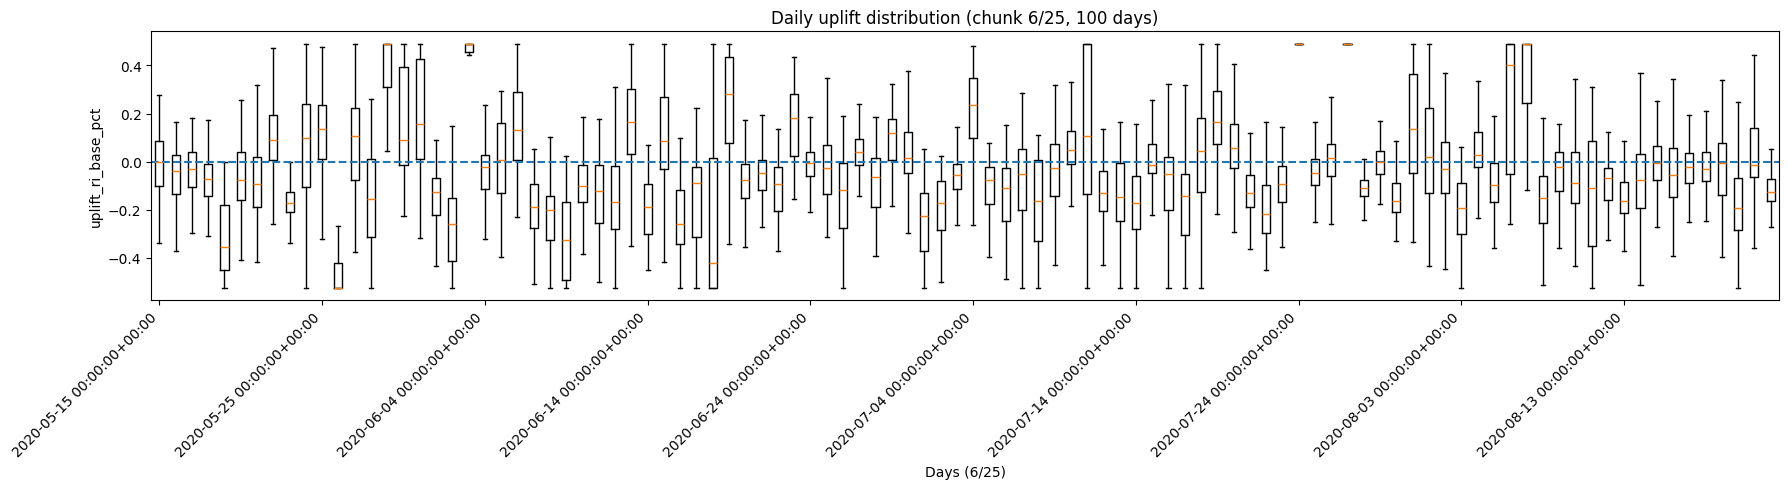

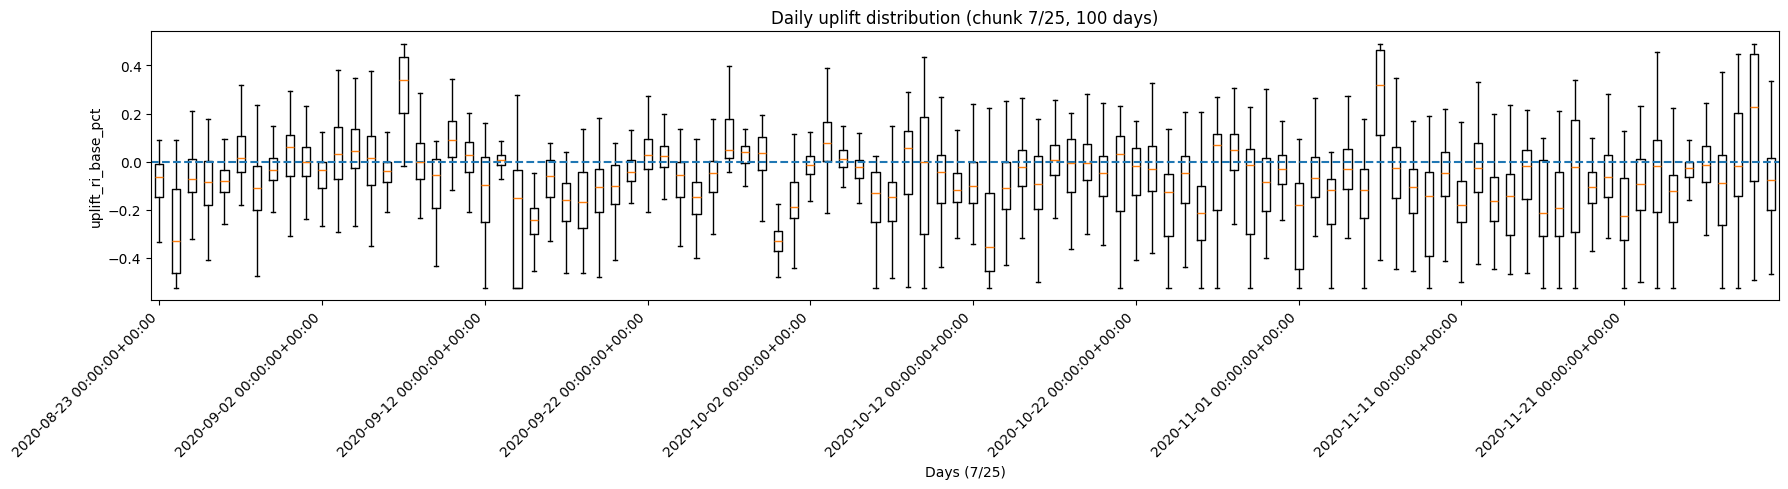

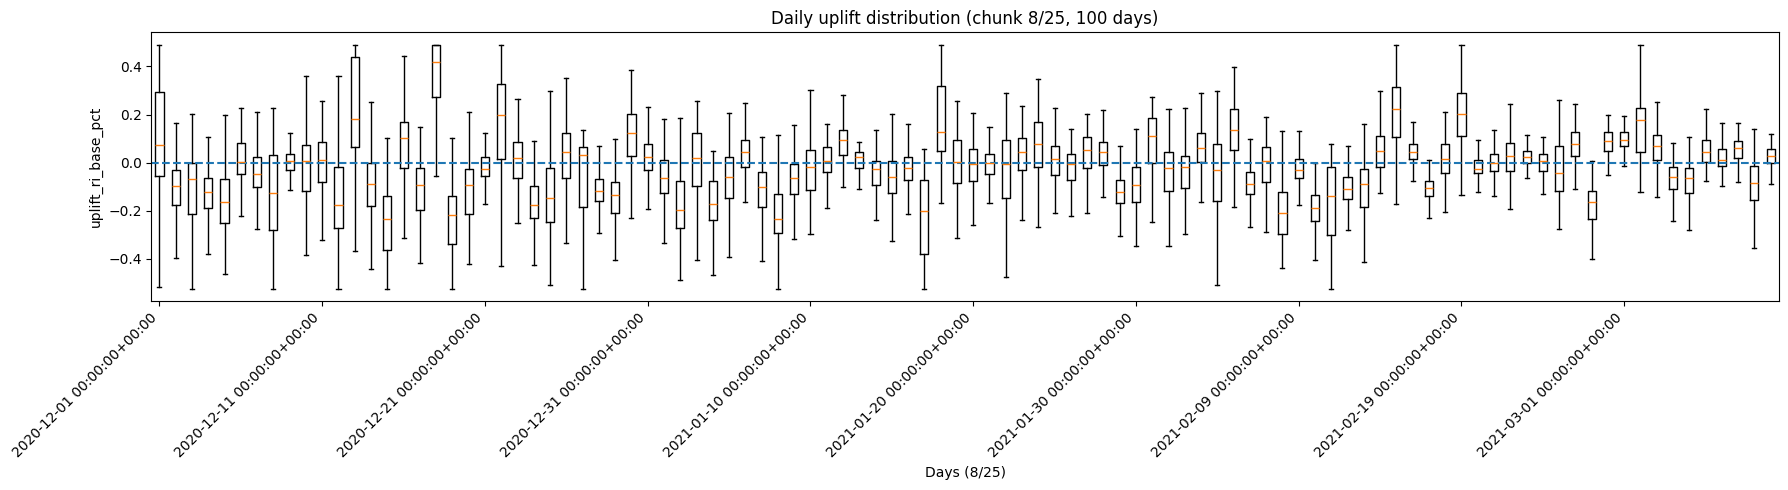

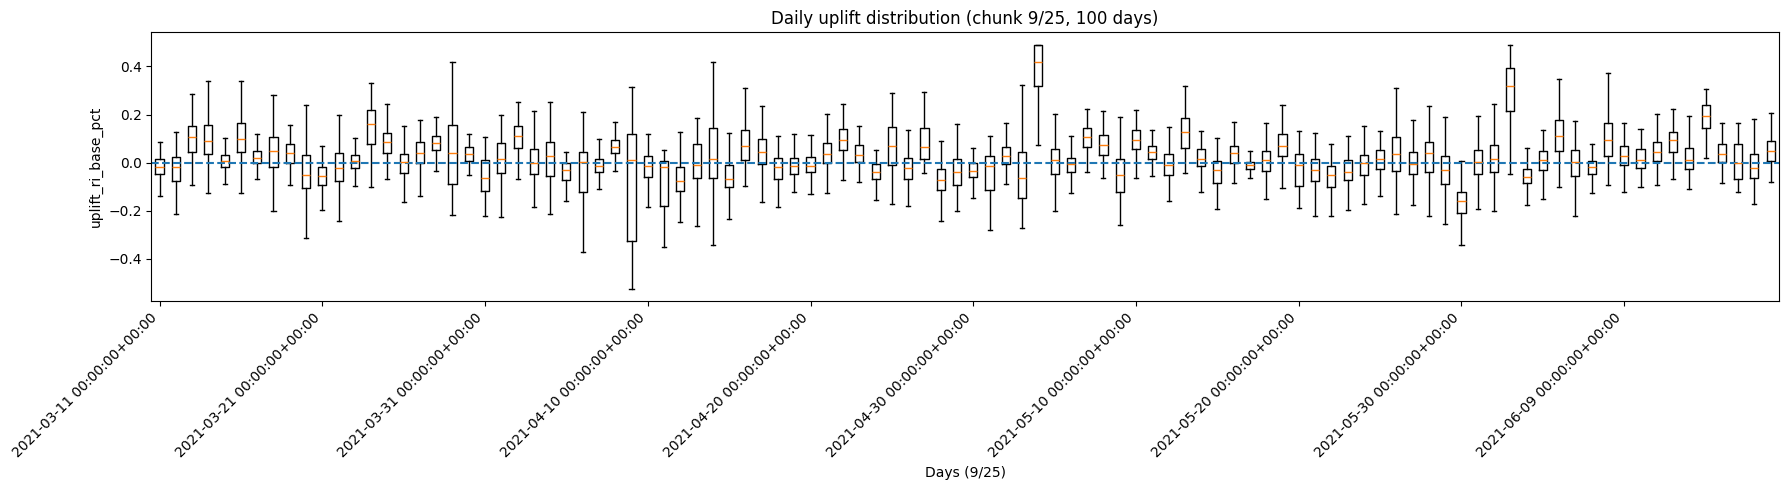

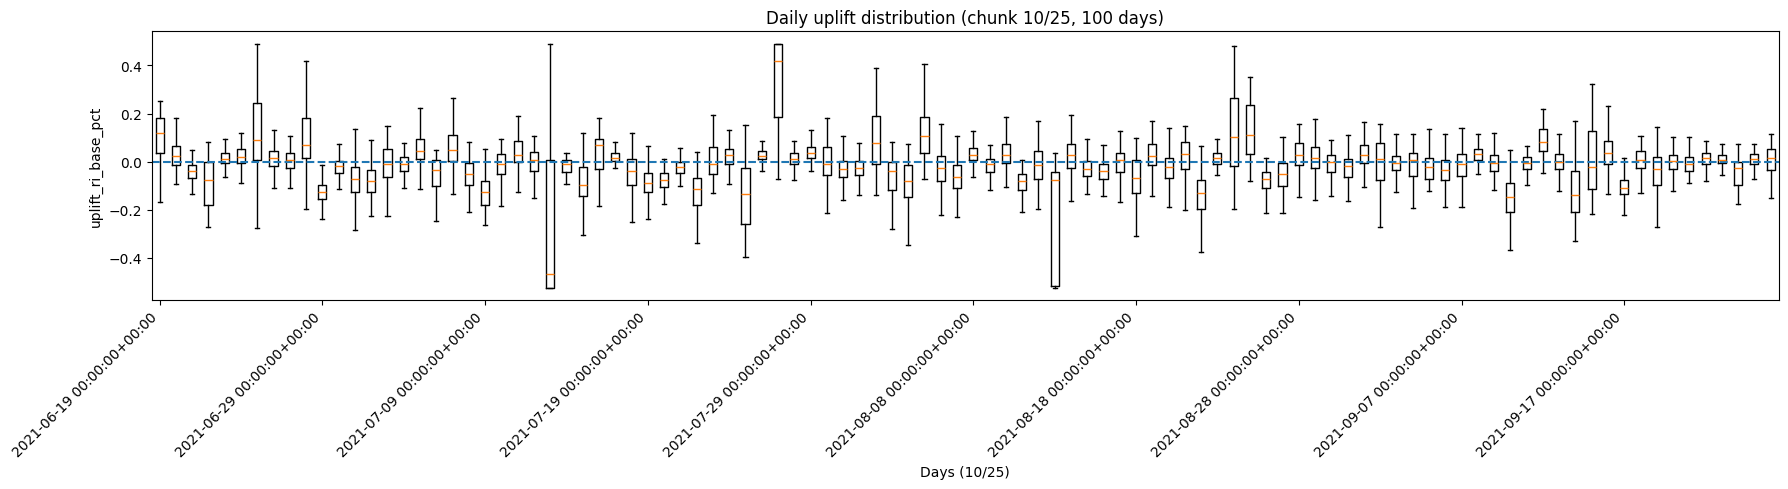

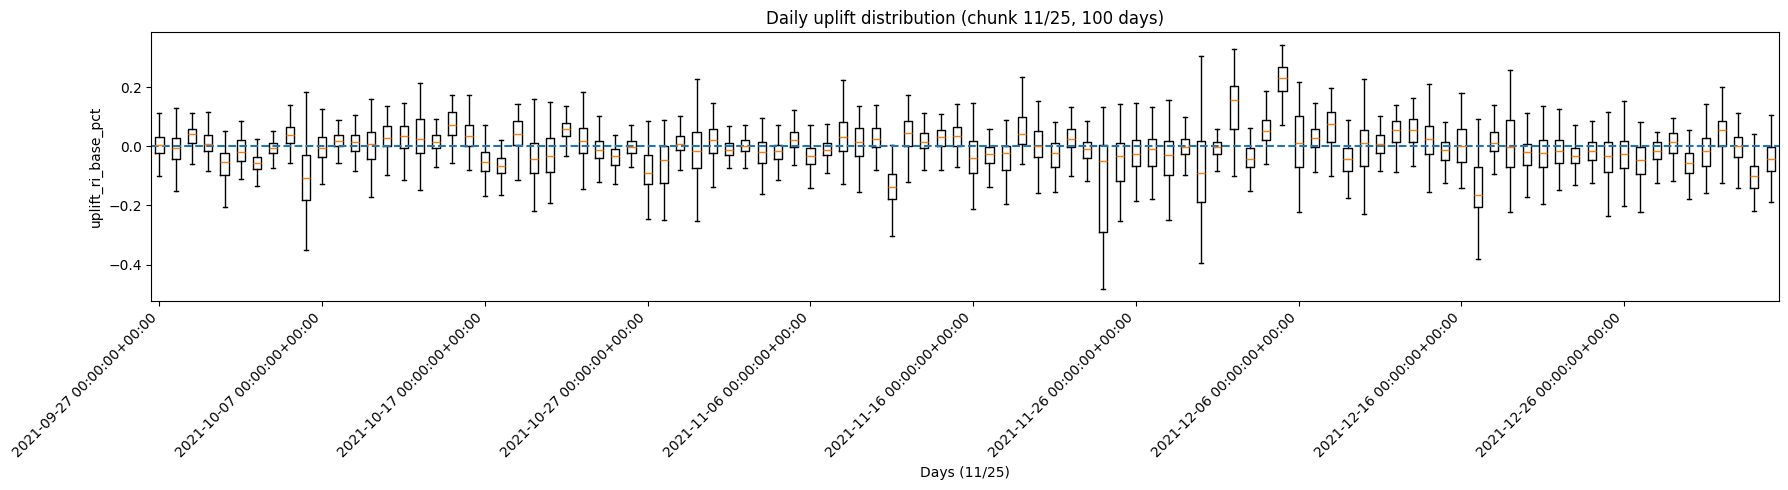

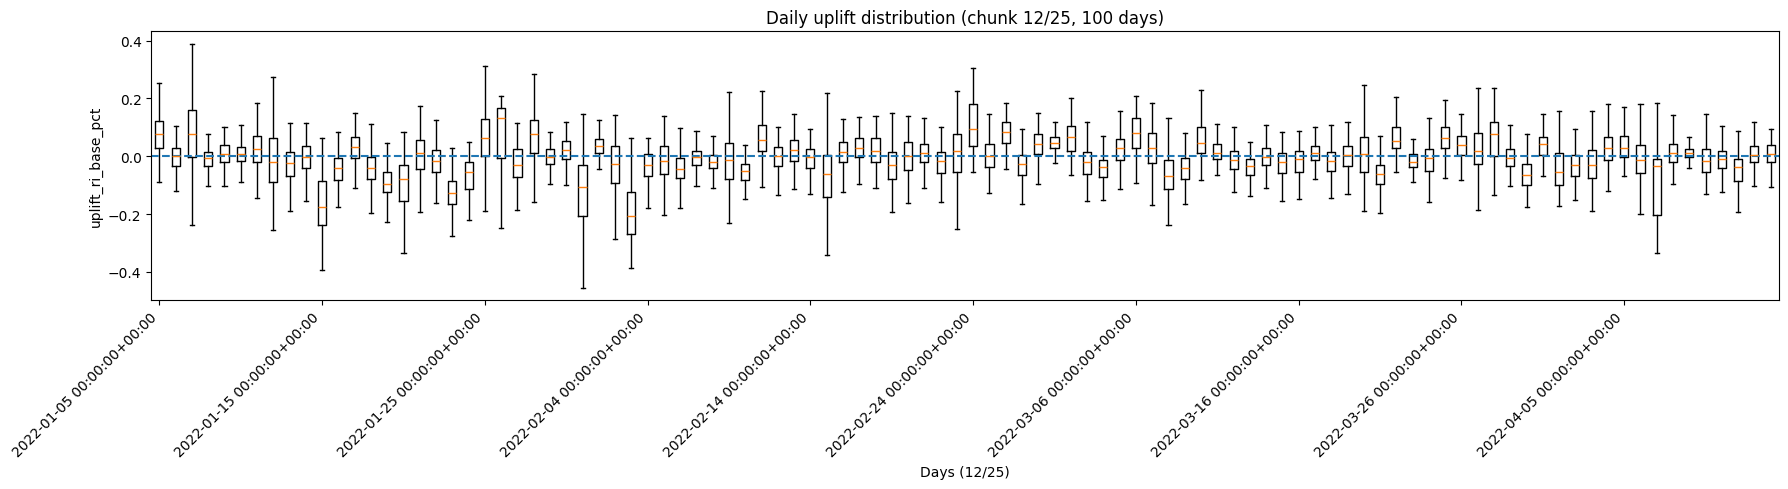

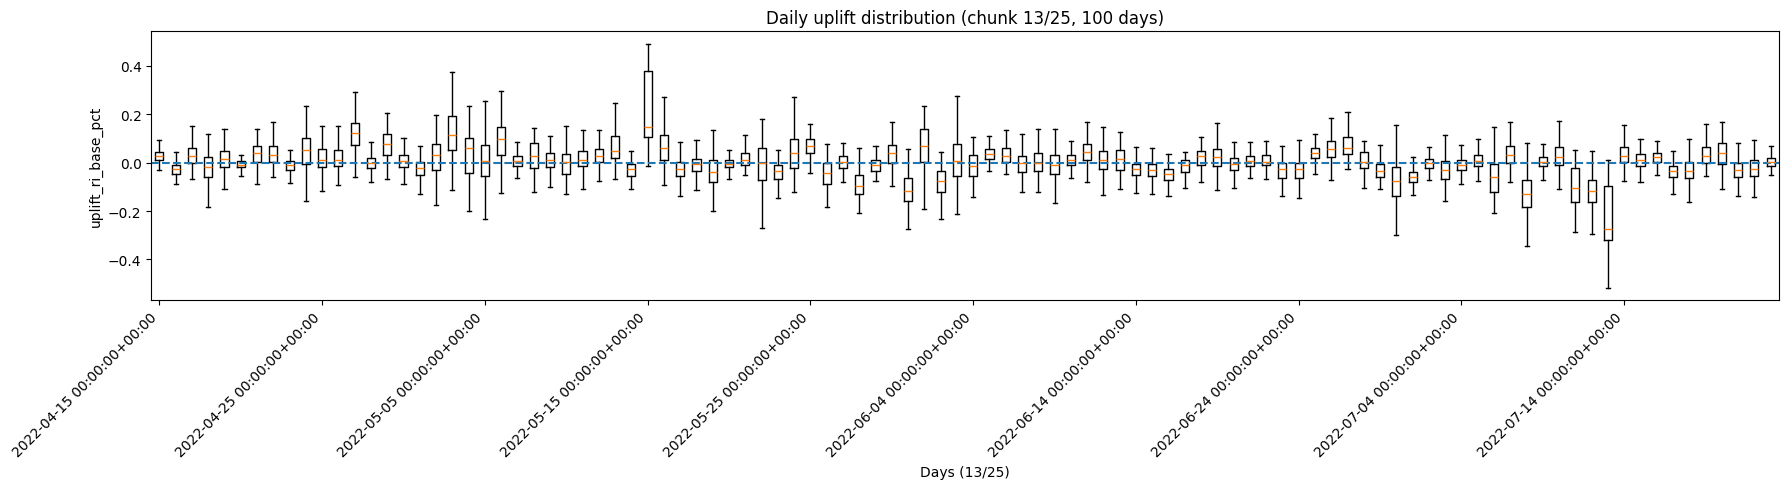

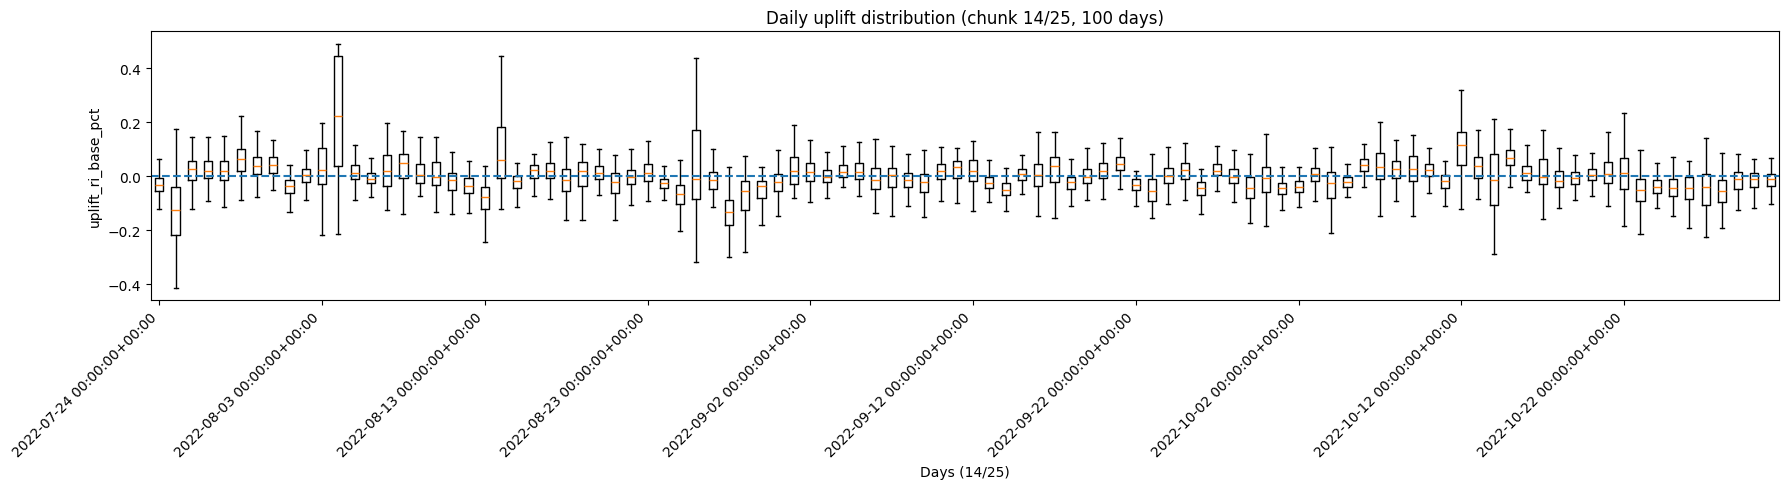

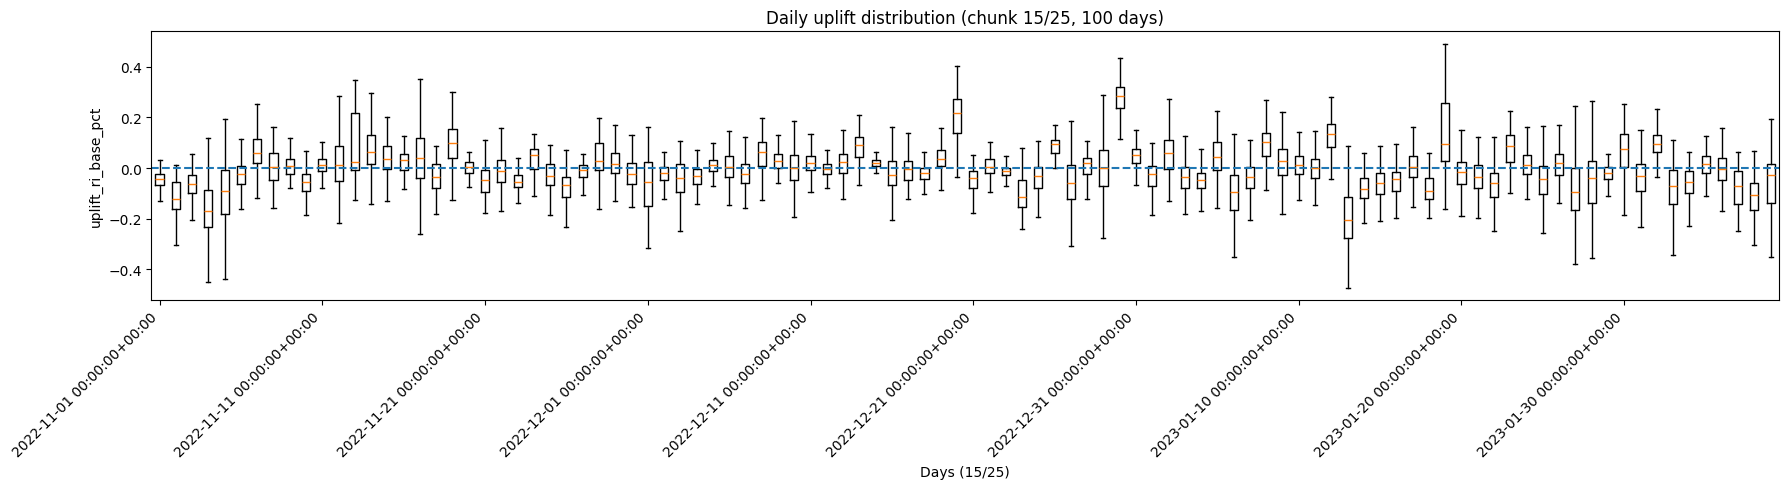

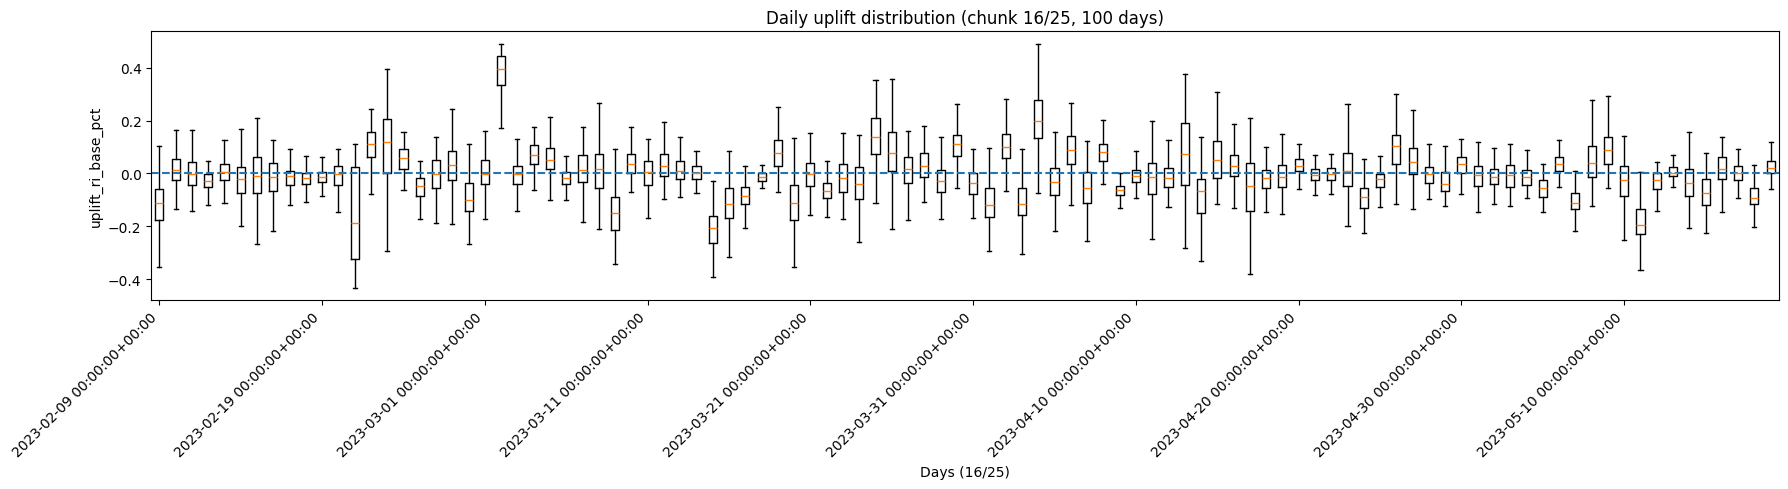

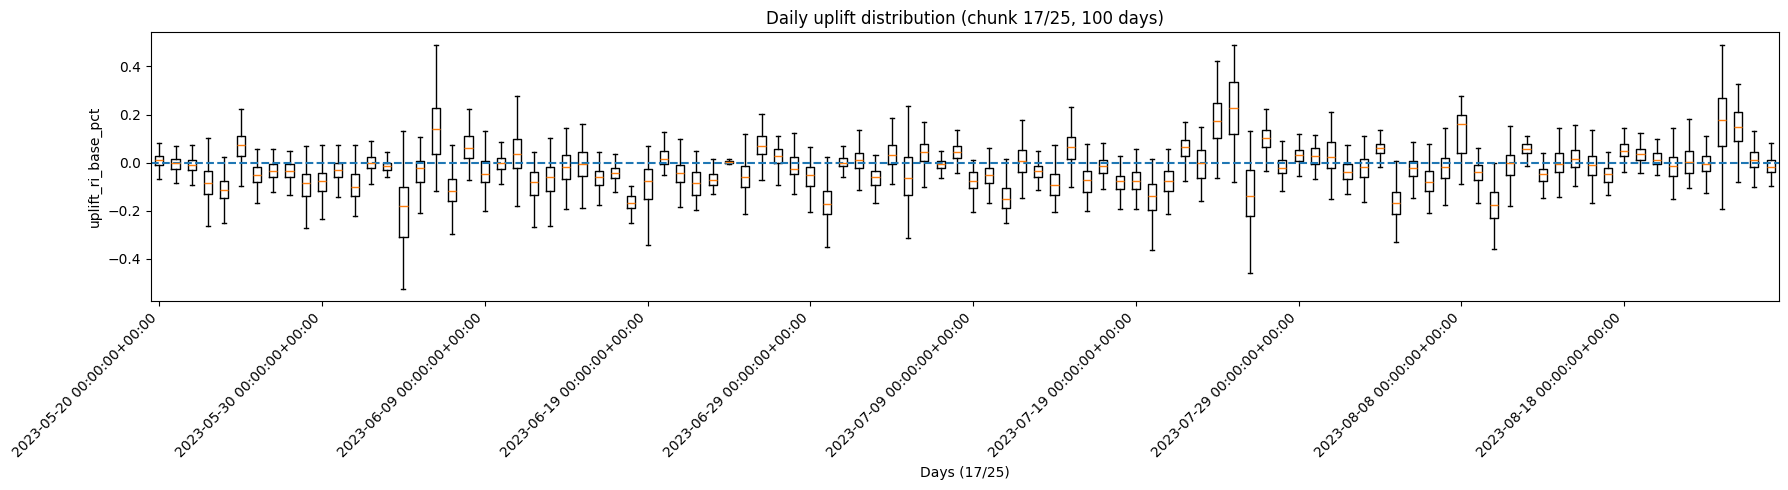

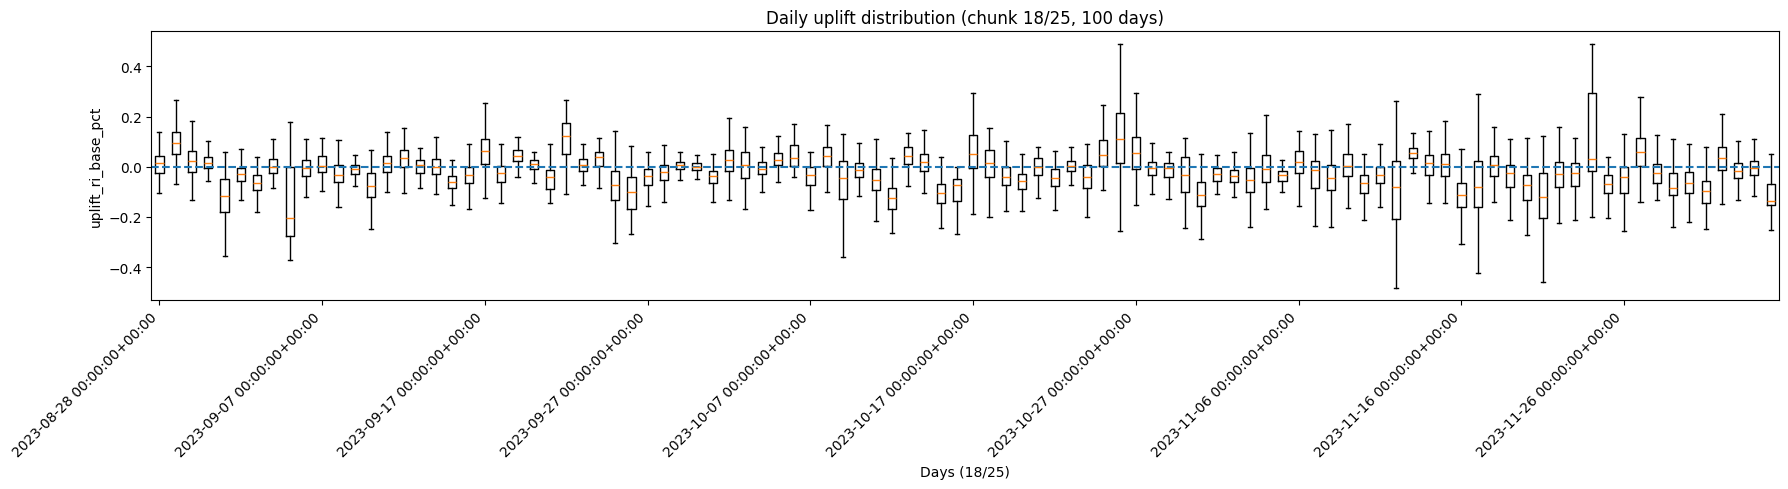

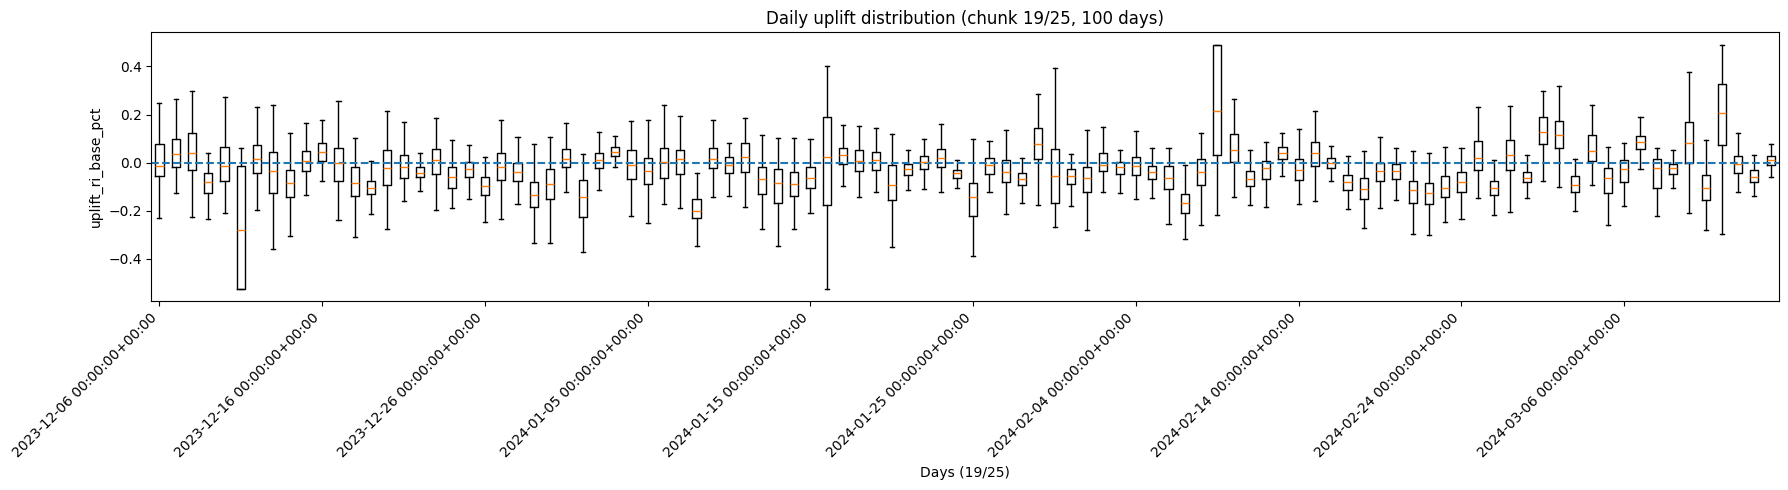

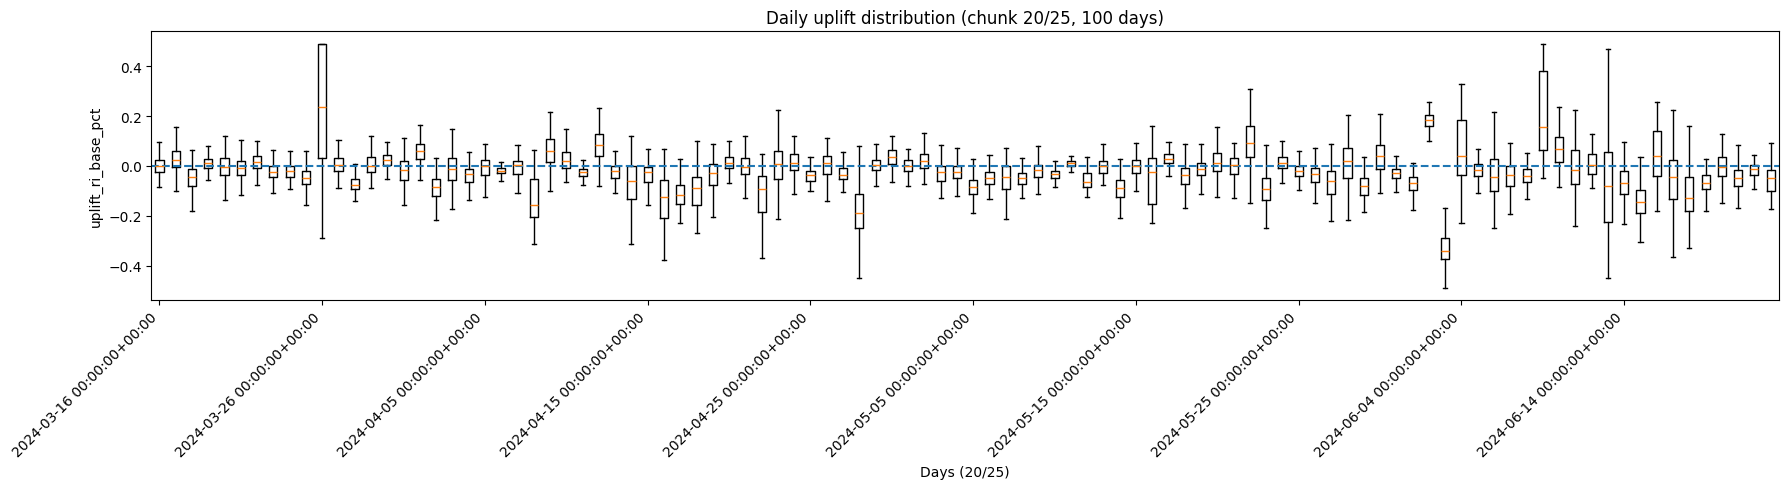

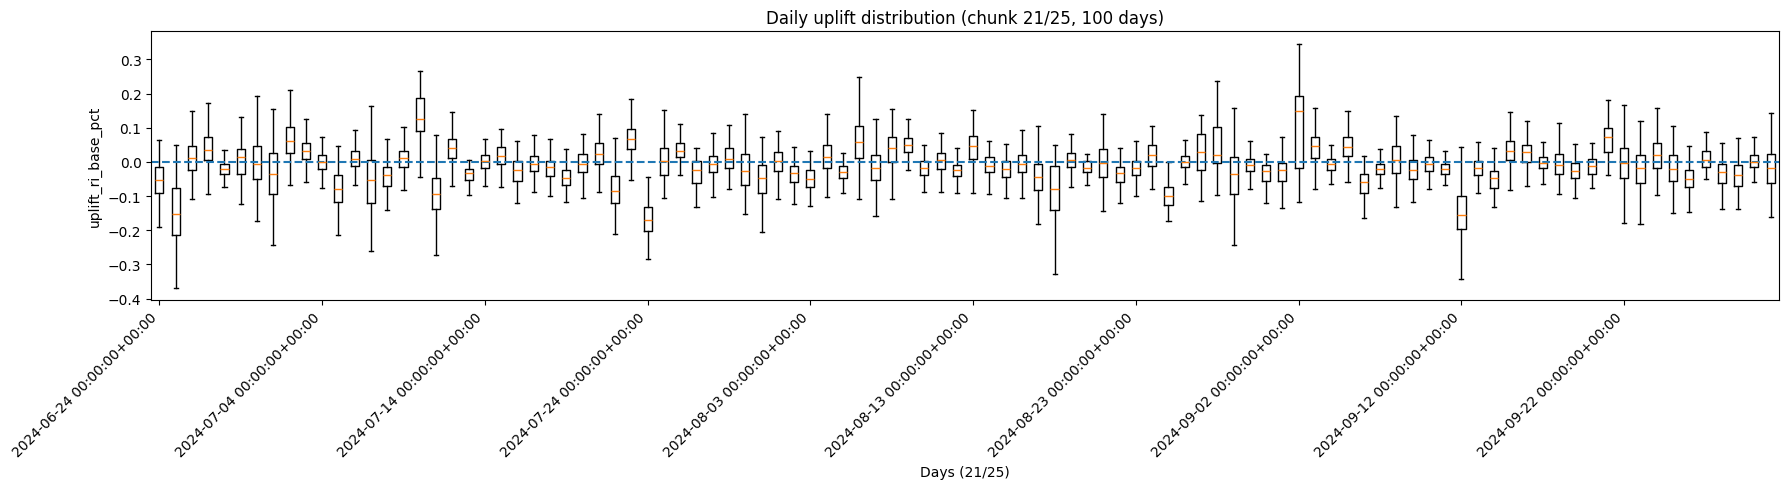

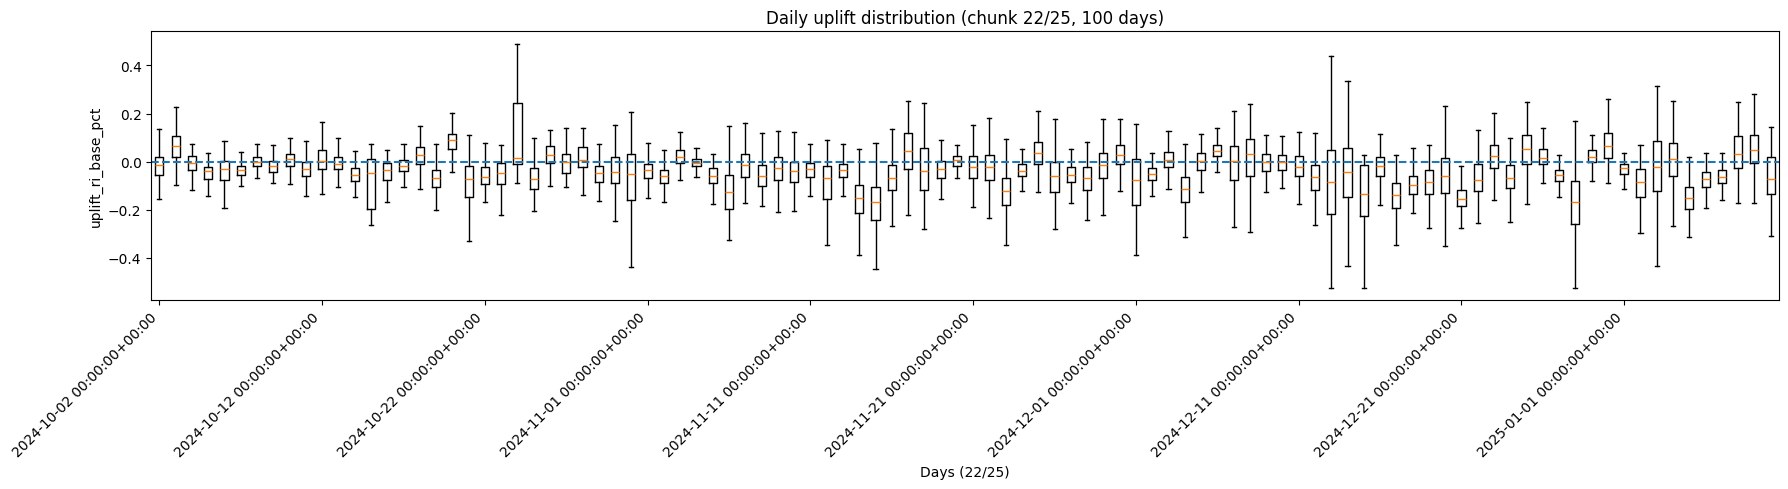

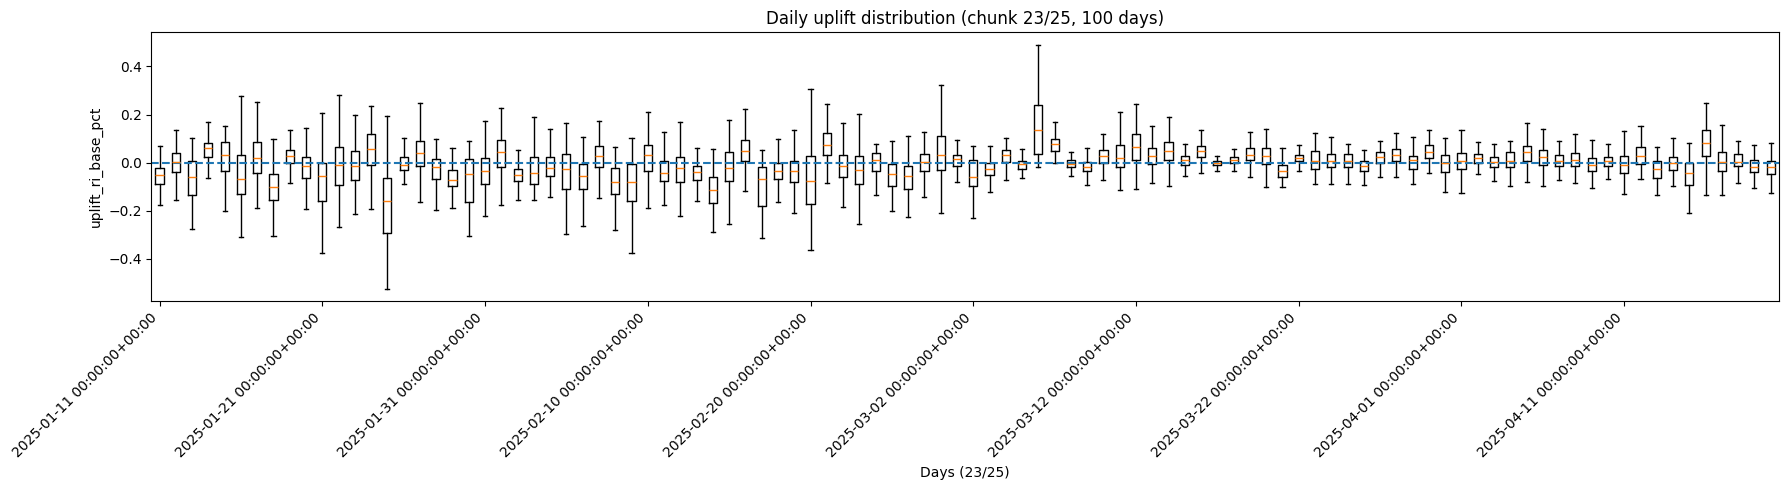

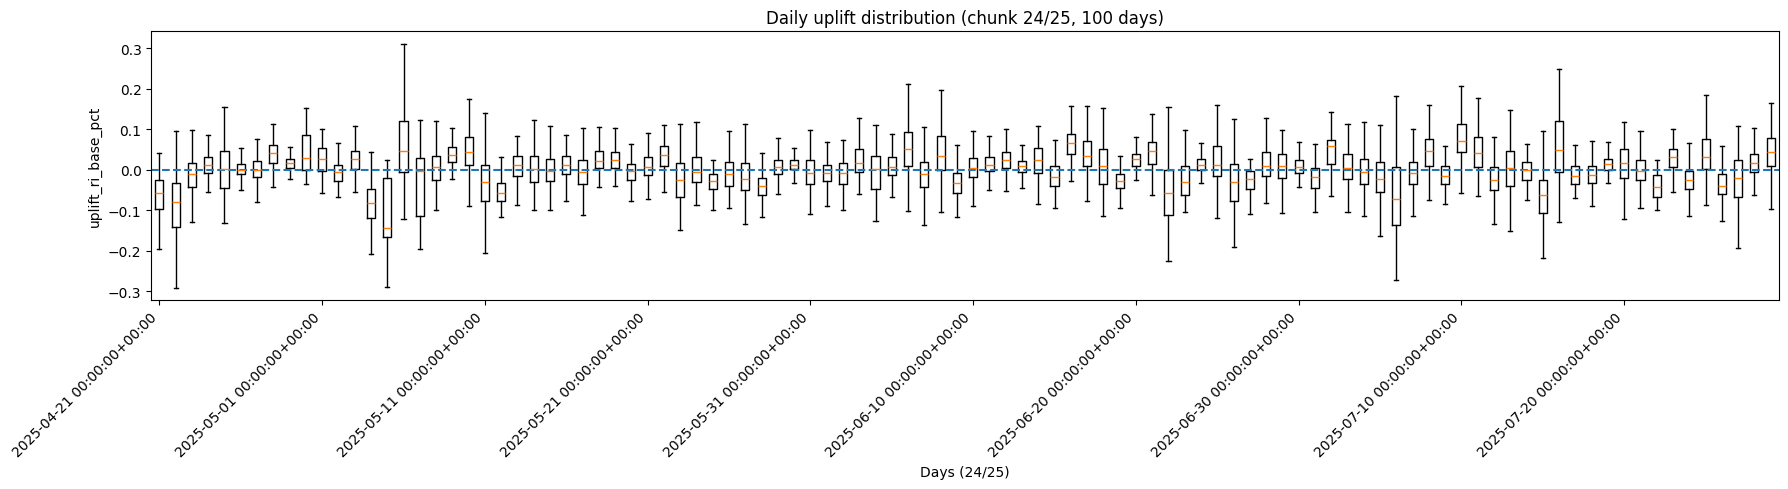

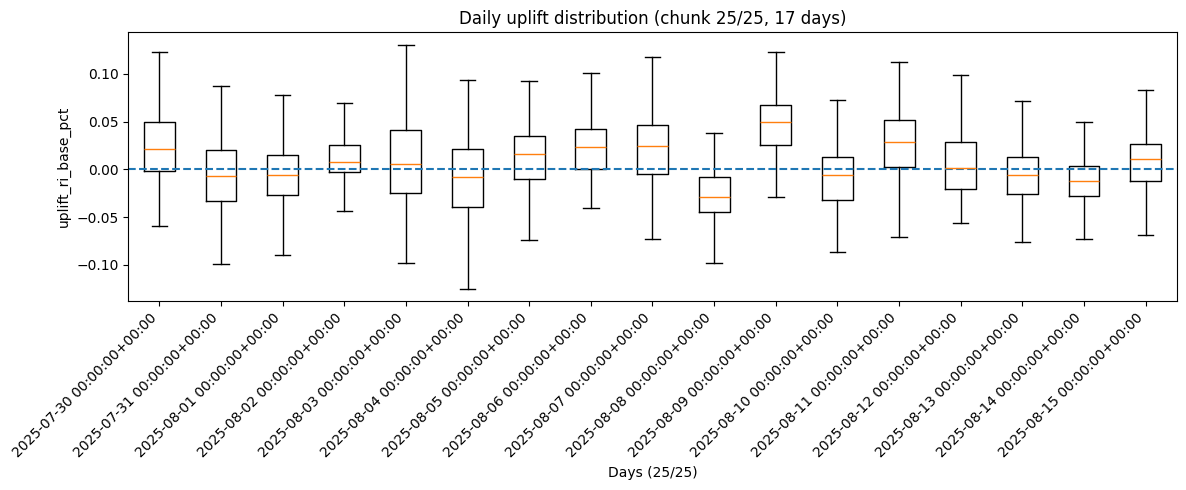

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_boxplots_by_day_chunks(
    df: pd.DataFrame,
    date_col: str = "date",
    value_col: str = "uplift_ri_base_pct",
    chunk_size: int = 80,
    sort_days: str = "day",   # "date" oder "median" oder "mean"
    showfliers: bool = False,
):
    d = df[[date_col, value_col]].dropna().copy()

    # Liste aller Tage
    days = d[date_col].drop_duplicates()

    # Sortierung (optional hilfreich)
    if sort_days == "median":
        day_order = (d.groupby(date_col)[value_col].median()
                       .sort_values(ascending=True).index.tolist())
    elif sort_days == "mean":
        day_order = (d.groupby(date_col)[value_col].mean()
                       .sort_values(ascending=True).index.tolist())
    else:
        # nach Datum (sicher, wenn date echtes Date/Datetime ist)
        day_order = sorted(days.tolist())

    # Daten pro Tag einmal vorbereiten (spart Zeit)
    grouped = {day: d.loc[d[date_col] == day, value_col].values for day in day_order}

    n = len(day_order)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in range(n_chunks):
        chunk_days = day_order[i*chunk_size:(i+1)*chunk_size]
        data = [grouped[day] for day in chunk_days]

        plt.figure(figsize=(max(12, len(chunk_days)*0.18), 5))
        plt.boxplot(data, showfliers=showfliers)

        # Baseline-Linie
        plt.axhline(0, linestyle="--")

        # X-Achse: nicht jeden Tag labeln (sonst zu voll)
        tick_step = max(1, len(chunk_days)//10)
        ticks = np.arange(1, len(chunk_days)+1, tick_step)
        labels = [str(chunk_days[t-1]) for t in ticks]

        plt.xticks(ticks, labels, rotation=45, ha="right")
        plt.xlabel(f"Days ({i+1}/{n_chunks})")
        plt.ylabel(value_col)
        plt.title(f"Daily uplift distribution (chunk {i+1}/{n_chunks}, {len(chunk_days)} days)")
        plt.tight_layout()
        plt.show()

#q01, q99 = df["uplift_pct"].quantile([0.01, 0.99])
#df["uplift_pct_plot"] = df["uplift_pct"].clip(q01, q99)

q01, q99 = df["uplift_ri_base_pct"].quantile([0.01, 0.99])
df["uplift_ri_base_pct"] = df["uplift_ri_base_pct"].clip(q01, q99)
# Aufruf
plot_boxplots_by_day_chunks(
    df,
    date_col="day",
    value_col="uplift_ri_base_pct",
    chunk_size=100,
    sort_days="day",
    showfliers=False
)

Random day file: results_merged/summary_2020-09-18.csv


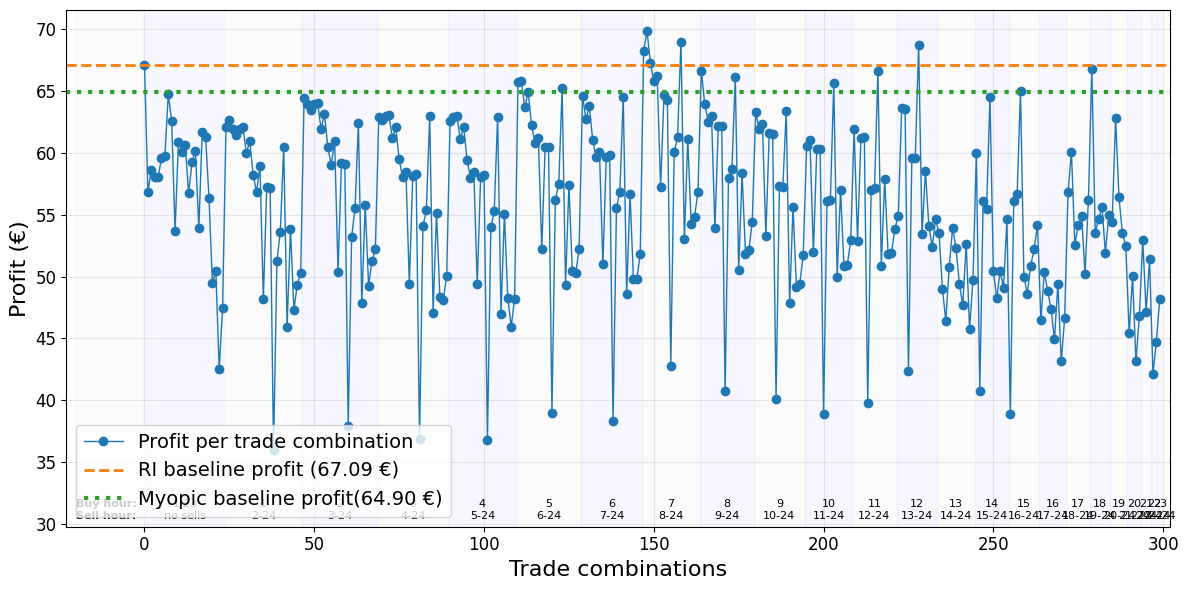

In [54]:
import random

# name plot
name = "ri_combos"

# Load a random day's full combination results
oracle_dir = Path("./results_merged")
files = sorted(oracle_dir.glob("summary_*.csv"))

# Pick one random file (one random day)
random_file = random.choice(files)
print(f"Random day file: {random_file}")

# Read the day's data
# Assumes columns at least: 'combo_id', 'profit', 'da_profit'
day_df = pd.read_csv(random_file)

# Sort by combo_id so the x-axis is ordered
if "combo_id" not in day_df.columns:
    raise ValueError("Expected column 'combo_id' in summary file.")

if "profit" not in day_df.columns:
    raise ValueError("Expected column 'profit' in summary file.")

if "da_profit" not in day_df.columns:
    raise ValueError("Expected column 'da_profit' in summary file.")

# Extract the day from the file or from data (if 'day' column exists)
plot_day_str = None
if "day" in day_df.columns:
    # Take first unique value
    plot_day_str = str(pd.to_datetime(day_df["day"].iloc[0]).date())
else:
    # Fallback: infer from filename like 'summary_2019-01-01.csv'
    plot_day_str = random_file.stem.replace("summary_", "")

# Sort
day_df = day_df.sort_values("combo_id")

# Compute baseline values for this day
# RI baseline: combo_id == 0 (as in the main script)
ri_row = day_df.loc[day_df["combo_id"] == 0]
if ri_row.empty:
    raise ValueError("No combo_id == 0 found for RI baseline.")
ri_base_val = ri_row["profit"].iloc[0]

# Myopic baseline: row with max da_profit
myopic_row = day_df.loc[day_df["da_profit"].idxmax()]
myopic_base_val = myopic_row["profit"]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Line plot of profits over combo_id
ax.plot(day_df["combo_id"], day_df["profit"], marker="o", linestyle="-", linewidth=1.0, label="Profit per trade combination")

# Horizontal lines for baselines
ax.axhline(ri_base_val, color="tab:orange", linestyle="--", linewidth=2.0, label=f"RI baseline profit ({ri_base_val:.2f} €)")
ax.axhline(myopic_base_val, color="tab:green", linestyle=":", linewidth=3.0, label=f"Myopic baseline profit({myopic_base_val:.2f} €)")

# --- Structured bands on the x-axis ---
# We use your known structure:
#  - 0: no DA / baseline
#  - 1–23: buy-only
#  - from 24 onward: all buy<sell pairs, grouped by buy hour

bands = []
# Legend band to the far left (no real combos here, just text)
# Place well before combo_id 1 so the text doesn't overlap with real bands.
bands.append((-20, -1, "Buy hour:\nSell hour:"))

# First real band: buy-only trades (combo_ids 1..23)
bands.append((1, 23, "1-23\nno sells"))

# Remaining bands: for each buy hour b = 1..23, range of combos with buy=b, sell>b
# For buy hours 1–12, show labels like "1\n2-24", "2\n3-24", ...
# For later buy hours, leave the label empty to avoid clutter.
start = 24
for b in range(1, 24):  # buy hour
    length = 24 - b      # possible sell hours (b+1..24)
    end = start + length - 1
    if b <= 23:
        label = f"{b}\n{b+1}-24"
    else:
        label = ""
    bands.append((start, end, label))
    start = end + 1

# Compute y-limits for band annotation
ymin, ymax = ax.get_ylim()
y_span = ymax - ymin
text_y = ymin - 0.06 * y_span  # put text slightly below axis

# Alternate background colors and add labels
for i, (x0, x1, label) in enumerate(bands):
    color = "#f0f0f0" if i % 2 == 0 else "#e0e0ff"
    ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.25, zorder=-1)

    if i == 0:
        # Legend band: left-align text at the left edge of the band
        text_x = x0 - 0.3
        ha = "left"
        fs = 8
        fw = "bold"
    else:
        # Other bands: center text in the band
        text_x = (x0 + x1) / 2
        ha = "center"
        fs = 8
        fw = "normal"

    ax.text(text_x, text_y, label, ha=ha, va="top", fontsize=fs,fontweight=fw, rotation=0)

# Extend y-limits to make room for text
ax.set_ylim(ymin - 0.12 * y_span, ymax)

ax.set_xlabel("Trade combinations", fontsize=16)
ax.set_ylabel("Profit (€)", fontsize=16)
#ax.set_title(f"Profit per combo for day {plot_day_str}\nwith RI and myopic baselines and strategy bands", fontsize=16)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

ax.tick_params(labelsize=12)

# Use the min/max of all band ranges (including legend band)
x_min = min(x0 for x0, x1, _ in bands)
x_max = max(x1 for x0, x1, _ in bands)
# Add a small margin
pad = 3
ax.set_xlim(x_min - pad, x_max + pad)



fig.tight_layout()

filepath = os.path.join(folder, f"{name}_{random_file.stem}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()